Project Objectives:

1️ Predicting High-Priority Tickets

To develop a predictive model that identifies Priority 1 and Priority 2 incidents at an early stage, enabling proactive response and preventing potential service disruptions.

2️ Forecasting Incident Volume

To forecast incident volumes on a quarterly and annual basis, helping organizations plan resources, staffing, and technology requirements more effectively.

3️ Automated Ticket Tagging

To automatically assign the correct priority and responsible department to incoming tickets, reducing manual triage effort and minimizing reassignment delays.

4️ RFC and Failure Prediction

To predict Requests for Change (RFCs) and identify potential failures or misconfigurations in ITSM assets, supporting proactive change management and system stability.

In [ ]:
!pip install pymysql
!pip install mysql-connector

## READING DATA FROM MYSQL


In [ ]:
import mysql.connector
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import shap
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

In [ ]:
conn = mysql.connector.connect(
    host="18.136.157.135",
    user="dm_team",
    password="DM!$Team@&27920!",
    database="project_itsm"
)

In [ ]:
db_databases=pd.read_sql_query('show databases',conn)
print(db_databases)

             Database
0  information_schema
1        project_itsm


In [ ]:
db_tables=pd.read_sql_query('show tables',conn)
print(db_tables)

  Tables_in_project_itsm
0           dataset_list


In [ ]:
df=pd.read_sql_query('select * from dataset_list ',conn)
df

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4,0.601292279,...,,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1,SD0000007,2,,
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3,0.415049969,...,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1,SD0000011,1,,
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,NS,3,NA,0.517551335,...,,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1,SD0000017,,,
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4,0.642927218,...,,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1,SD0000025,,,
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4,0.345258343,...,,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1,SD0000029,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46601,SBA000464,application,Server Based Application,WBS000073,IM0047053,Closed,4,4,4,0.23189604,...,,31-03-2014 16:29,31-03-2014 16:29,"0,095",Other,1,SD0147021,,,
46602,SBA000461,application,Server Based Application,WBS000073,IM0047054,Closed,4,4,4,0.805153085,...,,31-03-2014 15:29,31-03-2014 15:29,"0,428333333",User error,1,SD0146967,,,
46603,LAP000019,computer,Laptop,WBS000091,IM0047055,Closed,5,5,5,0.917466294,...,,31-03-2014 15:32,31-03-2014 15:32,"0,071666667",Hardware,1,SD0146982,,,
46604,WBA000058,application,Web Based Application,WBS000073,IM0047056,Closed,4,4,4,0.701278158,...,,31-03-2014 15:42,31-03-2014 15:42,"0,116944444",Software,1,SD0146986,,,


## BASIC CHECKS

In [ ]:
df.head()

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4,0.601292279,...,,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1,SD0000007,2,,
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3,0.415049969,...,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1,SD0000011,1,,
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,NS,3,NA,0.517551335,...,,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1,SD0000017,,,
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4,0.642927218,...,,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1,SD0000025,,,
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4,0.345258343,...,,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1,SD0000029,,,


In [ ]:
df.tail()

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
46601,SBA000464,application,Server Based Application,WBS000073,IM0047053,Closed,4,4,4,0.23189604,...,,31-03-2014 16:29,31-03-2014 16:29,"0,095",Other,1,SD0147021,,,
46602,SBA000461,application,Server Based Application,WBS000073,IM0047054,Closed,4,4,4,0.805153085,...,,31-03-2014 15:29,31-03-2014 15:29,"0,428333333",User error,1,SD0146967,,,
46603,LAP000019,computer,Laptop,WBS000091,IM0047055,Closed,5,5,5,0.917466294,...,,31-03-2014 15:32,31-03-2014 15:32,"0,071666667",Hardware,1,SD0146982,,,
46604,WBA000058,application,Web Based Application,WBS000073,IM0047056,Closed,4,4,4,0.701278158,...,,31-03-2014 15:42,31-03-2014 15:42,"0,116944444",Software,1,SD0146986,,,
46605,DCE000077,hardware,DataCenterEquipment,WBS000267,IM0047057,Closed,3,3,3,0.902319509,...,,31-03-2014 22:47,31-03-2014 22:47,"0,586388889",Hardware,1,SD0147088,,,


In [ ]:
df.shape

(46606, 25)

In [ ]:
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   CI_Name                     46606 non-null  object
 1   CI_Cat                      46606 non-null  object
 2   CI_Subcat                   46606 non-null  object
 3   WBS                         46606 non-null  object
 4   Incident_ID                 46606 non-null  object
 5   Status                      46606 non-null  object
 6   Impact                      46606 non-null  object
 7   Urgency                     46606 non-null  object
 8   Priority                    46606 non-null  object
 9   number_cnt                  46606 non-null  object
 10  Category                    46606 non-null  object
 11  KB_number                   46606 non-null  object
 12  Alert_Status                46606 non-null  object
 13  No_of_Reassignments         46606 non-null  ob

In [ ]:
df.describe()

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
count,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,...,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606
unique,3019,13,65,274,46606,2,6,6,6,46606,...,2245,33628,34528,30639,15,50,43060,25,5,233
top,SUB000456,application,Server Based Application,WBS000073,IM0047057,Closed,4,4,4,0.902319509,...,,,02-10-2013 15:20,0,Other,1,#MULTIVALUE,,,
freq,3050,32900,18811,13342,1,46597,22556,22588,22717,1,...,44322,1780,21,236,16470,43058,3434,45384,46046,46046


In [ ]:
df1=df.copy()

## INSPECTING EVERY SINGLE COLUMN

#### 1.CI_NAME

CI_Name stands for Configuration Item Name. In IT Service Management (ITSM), a Configuration Item (CI) refers to any hardware or software component involved in an incident.
Each CI has a unique identifier, which is stored in the CI_Name column.
These values do not directly contain meaningful information, but they help identify which assets are frequently involved in incidents.

In [ ]:
df['CI_Name']

,CI_Name
0,SUB000508
1,WBA000124
2,DTA000024
3,WBA000124
4,WBA000124
...,...
46601,SBA000464
46602,SBA000461
46603,LAP000019
46604,WBA000058


In [ ]:
df['CI_Name'].value_counts()

,count
CI_Name,
SUB000456,3050
SBA000263,2176
SBA000607,1743
SBA000462,1698
WBA000058,1614
...,...
HMD000018,1
CBD000893,1
RTR000027,1


In [ ]:
df['CI_Name'].isnull().sum()

np.int64(0)

In [ ]:
df['CI_Name'].nunique()

3019

CI_Name column is a categorical variable representing asset identifiers. However, it has 3019 unique values and no null values are found, which makes it a high-cardinality categorical feature. Since such features are difficult for standard ML models to process directly, it requires specialized treatment such as frequency encoding, grouping, or dropping depending on the model use case.

#### 2.CI_Cat

The CI_Cat column represents the category of the Configuration Item (CI) associated with each incident. In IT Service Management (ITSM), a Configuration Item refers to any component in the IT infrastructure.

In [ ]:
df['CI_Cat']

,CI_Cat
0,subapplication
1,application
2,application
3,application
4,application
...,...
46601,application
46602,application
46603,computer
46604,application


In [ ]:
df['CI_Cat'].value_counts()

,count
CI_Cat,
application,32900
subapplication,7782
computer,3643
storage,703
hardware,442
software,333
database,214
displaydevice,212
officeelectronics,152


In [ ]:
df['CI_Cat'].nunique()

13

In [ ]:
df['CI_Cat'].isnull().sum()

np.int64(0)

There are 13 unique values in this column and no missing data, indicating that the entries are consistent and complete.
This is a categorical column that helps in identifying the general type of system or component involved in each incident.

#### 3.CI_Subcat

The CI_Subcat column specifies the subcategory of the Configuration Item (CI) involved in each incident. It provides more detailed information compared to CI_Cat and describes the specific type or platform of the affected system.

In [ ]:
df['CI_Subcat']

,CI_Subcat
0,Web Based Application
1,Web Based Application
2,Desktop Application
3,Web Based Application
4,Web Based Application
...,...
46601,Server Based Application
46602,Server Based Application
46603,Laptop
46604,Web Based Application


In [ ]:
df['CI_Subcat'].value_counts()

,count
CI_Subcat,
Server Based Application,18811
Web Based Application,15311
Desktop Application,3876
Laptop,1921
SAP,1199
...,...
Windows Server in extern beheer,1
Virtual Tape Server,1
RAC Service,1


In [ ]:
df['CI_Subcat'].nunique()

65

In [ ]:
df['CI_Subcat'].isnull().sum()

np.int64(0)

This column contains 65 distinct values and no missing entries, indicating that the data is complete. The values represent detailed classifications of IT assets involved in incidents.

#### 4.WBS

The WBS column contains identifiers related to the Work Breakdown Structure. In project and IT operations, WBS codes are used to track tasks, cost centers, or organizational units linked to an incident.

In [ ]:
df['WBS']

,WBS
0,WBS000162
1,WBS000088
2,WBS000092
3,WBS000088
4,WBS000088
...,...
46601,WBS000073
46602,WBS000073
46603,WBS000091
46604,WBS000073


In [ ]:
df['WBS'].value_counts()

,count
WBS,
WBS000073,13342
WBS000091,2500
WBS000263,2283
WBS000072,2197
WBS000271,1186
...,...
WBS000001,1
WBS000004,1
WBS000144,1


In [ ]:
df['WBS'].nunique()

274

In [ ]:
df['WBS'].isnull().sum()

np.int64(0)

This column includes 274 unique values and no missing data, indicating a detailed breakdown of various work or responsibility units associated with each incident. The values in this field serve as structured identifiers rather than descriptive text.

#### 5.Incident_ID

The Incident_ID column represents the unique identifier assigned to each incident or ticket in the IT Service Management system. Each row has a distinct Incident ID, which serves as a primary reference to track individual incidents throughout their lifecycle.

In [ ]:
df['Incident_ID']

,Incident_ID
0,IM0000004
1,IM0000005
2,IM0000006
3,IM0000011
4,IM0000012
...,...
46601,IM0047053
46602,IM0047054
46603,IM0047055
46604,IM0047056


In [ ]:
df['Incident_ID'].value_counts()

,count
Incident_ID,
IM0047057,1
IM0000004,1
IM0000005,1
IM0000006,1
IM0000011,1
...,...
IM0000033,1
IM0000031,1
IM0000028,1


In [ ]:
df['Incident_ID'].nunique()

46606

In [ ]:
df['Incident_ID'].isnull().sum()

np.int64(0)

This contains 46,606 distinct values with no missing entries, indicating that every record in the dataset has a unique incident reference and there are no duplicates or null values present.

#### 6.Status

The Status column indicates the current state of each incident in the system.

In [ ]:
df['Status']

,Status
0,Closed
1,Closed
2,Closed
3,Closed
4,Closed
...,...
46601,Closed
46602,Closed
46603,Closed
46604,Closed


In [ ]:
df['Status'].value_counts()

,count
Status,
Closed,46597
Work in progress,9


In [ ]:
df['Status'].nunique()

2

In [ ]:
df['Status'].isnull().sum()

np.int64(0)

It contains two unique values: “Closed” and “Work in Progress”. The majority of incidents (46597 records) are marked as Closed, while only 9 records are labeled as Work in Progress. There are no missing values, and the column clearly reflects the resolution stage of each incident.

#### 7.Impact

The Impact column represents the level of effect an incident has on the business or IT services.

In [ ]:
df['Impact']

,Impact
0,4
1,3
2,NS
3,4
4,4
...,...
46601,4
46602,4
46603,5
46604,4


In [ ]:
df['Impact'].value_counts()

,count
Impact,
4,22556
5,16741
3,5234
NS,1380
2,692
1,3


In [ ]:
df['Impact'].nunique()

6

In [ ]:
df['Impact'].isnull().sum()

np.int64(0)

t contains six unique values, with no missing entries. The majority of incidents are categorized as Impact 4 (22,556 records) and Impact 5 (16,741 records). Other values include Impact 3 (5,234 records), NS (Not Specified) with 1,380 records, Impact 2 with 692 records, and Impact 1 with only 3 records. This column reflects how severely each incident affects operations.

In [ ]:
df["Impact"] = df["Impact"].replace("NS", -1)
df["Impact"] = df["Impact"].astype(int)

The Impact column contained an 'NS' (Not Specified) value. Since this accounts for only 2–3% of the data, it was converted into a separate category (-1) instead of being removed. This approach preserves data integrity while allowing the model to identify incidents with unspecified impact.The datatype is converted as integers



#### 8.Urgency

The Urgency column represents how quickly an incident needs to be addressed.

In [ ]:
df['Urgency']

,Urgency
0,4
1,3
2,3
3,4
4,4
...,...
46601,4
46602,4
46603,5
46604,4


In [ ]:
df['Urgency'].value_counts()

,count
Urgency,
4,22588
5,16779
3,6536
2,696
1,6
5 - Very Low,1


In [ ]:
df['Urgency'].nunique()

6

In [ ]:
df['Urgency'].isnull().sum()

np.int64(0)

It contains six unique values with no missing entries. Most incidents are labeled with urgency levels 4 (22,588 records) and 5 (16,779 records), while lower urgency levels such as 3 (6,536 records), 2 (696 records), and 1 (6 records) appear less frequently. Additionally, there is a special entry labeled “5 - Very Low”, which appears only once and is likely formatted differently compared to the other values. This column describes the response priority of each incident based on the speed of resolution required.

In [ ]:
df['Urgency'] = df['Urgency'].astype(str).str.extract('(\d+)').astype(int)

The Urgency column had a formatted entry (“5 - Very Low”) that was inconsistent with other numeric values. To maintain uniformity, only the numeric component was extracted, and the column was converted to integer type. This preserved the original meaning while ensuring data consistency for analysis.

#### 9.Priority

The Priority column specifies the urgency level assigned to each incident.

In [ ]:
df['Priority']

,Priority
0,4
1,3
2,NA
3,4
4,4
...,...
46601,4
46602,4
46603,5
46604,4


In [ ]:
df['Priority'].value_counts()

,count
Priority,
4,22717
5,16486
3,5323
NA,1380
2,697
1,3


In [ ]:
df['Priority'].nunique()

6

In [ ]:
df['Priority'].isnull().sum()

np.int64(0)

t contains six distinct values and no missing entries. Most incidents fall under Priority 4 (22,717 records) and Priority 5 (16,486 records), indicating a larger number of lower-priority cases. Other values include Priority 3 (5,323 records), Priority 2 (697 records), and Priority 1, which appears only 3 times. Additionally, the column includes 1,380 records labeled as “NA”, representing cases where the priority was not specified.

In [ ]:
df["Priority"] = df["Priority"].replace("NA", -1).astype(int)

The Priority column originally contained five numeric values (1–5) and a separate category labeled “NA” for unspecified priority levels. To ensure consistency, the “NA” values were converted into a distinct numerical category (-1) and the entire column was converted to integer type. This approach preserves data completeness and maintains a clear distinction between specified and unspecified priority assignments.

#### 10.number_cnt

In [ ]:
df['number_cnt']

,number_cnt
0,0.601292279
1,0.415049969
2,0.517551335
3,0.642927218
4,0.345258343
...,...
46601,0.23189604
46602,0.805153085
46603,0.917466294
46604,0.701278158


In [ ]:
df['number_cnt'].value_counts()

,count
number_cnt,
0.902319509,1
0.601292279,1
0.415049969,1
0.517551335,1
0.642927218,1
...,...
0.860254961,1
0.151630128,1
0.440612692,1


In [ ]:
df['number_cnt'].nunique()

46606

In [ ]:
df['number_cnt'].isnull().sum()

np.int64(0)

The number_cnt column contains unique values for every record, with no missing entries. Since all values in this column are distinct and do not repeat, it appears to function as an identifier-like field rather than a meaningful feature. This suggests that number_cnt does not provide useful variation for analysis or modeling and may act as a simple counter or internal reference number.

#### 11.Category

The Category column indicates the type of incident or request recorded in the system.

In [ ]:
df['Category']

,Category
0,incident
1,incident
2,request for information
3,incident
4,incident
...,...
46601,incident
46602,incident
46603,incident
46604,incident


In [ ]:
df['Category'].value_counts()

,count
Category,
incident,37748
request for information,8846
complaint,11
request for change,1


In [ ]:
df['Category'].nunique()

4

In [ ]:
df['Category'].isnull().sum()

np.int64(0)

It contains four distinct values with no missing entries. The majority of records fall under the “incident” category (37,748 records), followed by “request for information” (8,846 records). A very small number of records are labeled as “complaint” (11 entries) and “request for change” (1 entry). This field provides a basic classification of the nature of each ticket.

#### 12.KB_number

The KB_number column represents references to Knowledge Base articles associated with each incident.

In [ ]:
df['KB_number']

,KB_number
0,KM0000553
1,KM0000611
2,KM0000339
3,KM0000611
4,KM0000611
...,...
46601,KM0001314
46602,KM0002360
46603,KM0000315
46604,KM0001287


In [ ]:
df['KB_number'].value_counts()

,count
KB_number,
KM0001106,1106
KM0000940,864
KM0001444,790
KM0002043,773
KM0001825,725
...,...
KM0002062,1
KM0001642,1
KM0000948,1


In [ ]:
df['KB_number'].nunique()

1825

In [ ]:
df['KB_number'].isnull().sum()

np.int64(0)

It contains 1,875 unique values and no missing entries. Each value corresponds to a specific knowledge base record that may provide guidance, documentation, or solutions related to the incident. Since many of the entries are unique, this field functions as a reference identifier rather than a descriptive or analytical feature.

#### 13.Alert_Status

The Alert_Status column indicates the alert or notification state of the incident.

In [ ]:
df['Alert_Status']

,Alert_Status
0,closed
1,closed
2,closed
3,closed
4,closed
...,...
46601,closed
46602,closed
46603,closed
46604,closed


In [ ]:
df['Alert_Status'].value_counts()

,count
Alert_Status,
closed,46606


In [ ]:
df['Alert_Status'].isnull().sum()

np.int64(0)

It contains only a single unique value, “Closed”, across all records, with no missing entries. Since all incidents in this dataset have the same alert status, this field does not provide any variation or meaningful information for analysis or modeling.

#### 14.No_of_Reassignments

The No_of_Reassignments column represents the number of times an incident was reassigned from one team or individual to another during its resolution process.

In [ ]:
df['No_of_Reassignments']

,No_of_Reassignments
0,26
1,33
2,3
3,13
4,2
...,...
46601,0
46602,0
46603,0
46604,0


In [ ]:
df['No_of_Reassignments'].value_counts()

,count
No_of_Reassignments,
0,27468
1,7268
2,5378
3,2191
4,1606
5,721
6,622
7,329
8,246


In [ ]:
df['No_of_Reassignments'].nunique()

42

In [ ]:
df['No_of_Reassignments'].isnull().sum()

np.int64(0)

t contains a wide range of values with no missing entries. Most incidents have 0 reassignments (27,468 records), while a decreasing number of incidents show higher reassignment counts. The values gradually reduce as the number increases, reaching occasional cases with over 30 reassignments. This column reflects the complexity or difficulties encountered in resolving certain incidents.

#### 15.Open_Time  

The Open_Time column records the exact date and time when each incident was initially created in the system.

In [ ]:
df['Open_Time']

,Open_Time
0,05-02-2012 13:32
1,12-03-2012 15:44
2,29-03-2012 12:36
3,17-07-2012 11:49
4,10-08-2012 11:01
...,...
46601,31-03-2014 16:23
46602,31-03-2014 15:03
46603,31-03-2014 15:28
46604,31-03-2014 15:35


In [ ]:
df['Open_Time'].value_counts()

,count
Open_Time,
24-03-2014 08:54,7
07-02-2014 10:44,6
25-11-2013 10:52,6
21-02-2014 15:01,6
12-11-2013 11:04,6
...,...
02-10-2012 12:12,1
01-10-2012 10:49,1
21-09-2012 12:56,1


In [ ]:
df['Open_Time'].nunique()

34636

In [ ]:
df['Open_Time'].isnull().sum()

np.int64(0)

It contains 34,636 unique values and no missing entries. These timestamps indicate when incidents were reported and serve as temporal information for understanding the occurrence and distribution of incidents over time.

#### 16.Reopen_Time

The Reopen_Time column records the date and time when an incident was reopened after being previously closed.

In [ ]:
df['Reopen_Time']

,Reopen_Time
0,
1,02-12-2013 12:31
2,
3,
4,
...,...
46601,
46602,
46603,
46604,


In [ ]:
df['Reopen_Time'].value_counts()

,count
Reopen_Time,
,44322
20-03-2014 08:43,2
25-02-2014 15:27,2
06-11-2013 14:38,2
14-03-2014 14:29,2
...,...
13-11-2013 15:35,1
18-11-2013 12:09,1
13-11-2013 11:47,1


In [ ]:
df['Reopen_Time'].nunique()

2245

In [ ]:
df['Reopen_Time'].isnull().sum()

np.int64(0)

It contains a high number of empty entries, indicating that 44,322 records have no reopen time, meaning those incidents were not reopened. Only a small number of incidents include valid timestamps, showing the specific moments when they were revisited. This field reflects follow-ups or unresolved cases that required reactivation after closure.

#### 17.Resolved_Time

The Resolved_Time column represents the date and time when an incident was officially resolved.

In [ ]:
df['Resolved_Time']

,Resolved_Time
0,04-11-2013 13:50
1,02-12-2013 12:36
2,13-01-2014 15:12
3,14-11-2013 09:31
4,08-11-2013 13:55
...,...
46601,31-03-2014 16:29
46602,31-03-2014 15:29
46603,31-03-2014 15:32
46604,31-03-2014 15:42


In [ ]:
df['Resolved_Time'].value_counts()

,count
Resolved_Time,
,1780
10-10-2013 12:53,7
31-03-2014 09:20,6
16-12-2013 09:47,6
10-03-2014 09:41,6
...,...
08-11-2013 14:33,1
08-11-2013 14:02,1
08-11-2013 13:55,1


In [ ]:
df['Resolved_Time'].nunique()

33628

In [ ]:
df['Resolved_Time'].isnull().sum()

np.int64(0)

It contains 33,628 records with valid timestamps, while the remaining entries do not include resolution information. Some timestamps appear multiple times, indicating that multiple incidents were resolved at the same moment. This column provides important temporal information about the completion point of incidents and reflects the resolution stage within the incident lifecycle.

#### 18.Close_Time

The Close_Time column records the final date and time when an incident was officially closed in the system.

In [ ]:
df['Close_Time']

,Close_Time
0,04-11-2013 13:51
1,02-12-2013 12:36
2,13-01-2014 15:13
3,14-11-2013 09:31
4,08-11-2013 13:55
...,...
46601,31-03-2014 16:29
46602,31-03-2014 15:29
46603,31-03-2014 15:32
46604,31-03-2014 15:42


In [ ]:
df['Close_Time'].value_counts()

,count
Close_Time,
02-10-2013 15:20,21
03-12-2013 09:55,15
13-01-2014 15:09,13
21-02-2014 15:52,12
10-02-2014 12:29,11
...,...
08-11-2013 14:58,1
08-11-2013 14:22,1
08-11-2013 14:35,1


In [ ]:
df['Close_Time'].nunique()

34528

In [ ]:
df['Close_Time'].isnull().sum()

np.int64(0)

It contains 34,528 valid timestamp entries, showing the moments when incidents reached full completion. Some timestamps appear multiple times, indicating that several incidents were closed at the same time. This column captures the last step in the incident lifecycle and confirms that no further action was required after closure.

#### 19.Handle_Time_hrs

The Handle_Time_hrs column represents the total time taken to handle an incident, measured in hours.

In [ ]:
df['Handle_Time_hrs']

,Handle_Time_hrs
0,"3,87,16,91,111"
1,"4,35,47,86,389"
2,"4,84,31,19,444"
3,"4,32,18,33,333"
4,"3,38,39,03,333"
...,...
46601,"0,095"
46602,"0,428333333"
46603,"0,071666667"
46604,"0,116944444"


In [ ]:
df['Handle_Time_hrs'].value_counts()

,count
Handle_Time_hrs,
0,236
"0,034444444",23
"0,018333333",22
"0,016666667",19
"0,021388889",19
...,...
"2,54,80,55,556",1
"1,03,02,77,778",1
"1,18,36,11,111",1


In [ ]:
df['Handle_Time_hrs'].nunique()

30639

It contains 30,639 unique values, showing a wide range of handling durations. Some entries appear more than once, while many others are unique. The values are formatted with commas instead of decimal points (e.g., 0,034444444), indicating that the column is stored as text rather than numeric data. There are no missing entries.

#### 20.Closure_Code

The Closure_Code column specifies the reason or explanation provided when an incident was closed

In [ ]:
df['Closure_Code']

,Closure_Code
0,Other
1,Software
2,No error - works as designed
3,Operator error
4,Other
...,...
46601,Other
46602,User error
46603,Hardware
46604,Software


In [ ]:
df['Closure_Code'].value_counts()

,count
Closure_Code,
Other,16470
Software,13027
User error,3554
No error - works as designed,3530
Hardware,2999
Data,2209
Unknown,1590
Operator error,1539
User manual not used,765


In [ ]:
df['Closure_Code'].nunique()

15

. It contains multiple descriptive categories such as “Other”, “Software”, “User error”, “No error - works as designed”, “Hardware”, “Data”, “Unknown”, and others. The most frequently occurring values include Other (16,470 records), Software (13,027 records), and User error (3,554 records). Some entries consist of longer descriptive phrases, while others appear as single-word labels. This column categorizes how incidents were concluded and provides justification for their closure.

#### 21.No_of_Related_Interactions

The No_of_Related_Interactions column indicates the number of related interactions linked to each incident.

In [ ]:
df['No_of_Related_Interactions']

,No_of_Related_Interactions
0,1
1,1
2,1
3,1
4,1
...,...
46601,1
46602,1
46603,1
46604,1


In [ ]:
df['No_of_Related_Interactions'].value_counts()

,count
No_of_Related_Interactions,
1,43058
2,2736
3,429
4,124
,114
5,30
6,16
7,12
8,6


In [ ]:
df['No_of_Related_Interactions'].nunique()

50

Most records have only 1 related interaction (43,058 entries), while higher counts occur less frequently. There are cases with multiple related interactions ranging from 2 to over 300, although such higher values are relatively rare. This column provides a numerical count of interaction links for each incident and has no missing entries.

#### 22.Related_Interaction

The Related_Interaction column contains references to any interaction records associated with an incident.

In [ ]:
df['Related_Interaction']

,Related_Interaction
0,SD0000007
1,SD0000011
2,SD0000017
3,SD0000025
4,SD0000029
...,...
46601,SD0147021
46602,SD0146967
46603,SD0146982
46604,SD0146986


In [ ]:
df['Related_Interaction'].value_counts()

,count
Related_Interaction,
#MULTIVALUE,3434
#N/B,114
SD0095431,1
SD0095429,1
SD0095433,1
...,...
SD0045617,1
SD0045636,1
SD0045637,1


In [ ]:
df['Related_Interaction'].nunique()

43060

It includes specific interaction IDs (such as SD0095431, SD0045601, etc.), along with special entries like #MULTIVALUE and #N/B. The majority of values are unique, while 3,434 records are marked as #MULTIVALUE, indicating that multiple interactions are linked, and 114 records contain #N/B, which suggests unavailable or unspecified data. This column serves mainly as a reference field and does not contain descriptive information.

#### 23.No_of_Related_Incidents

The No_of_Related_Incidents column indicates the number of other incidents linked to a particular record.

In [ ]:
df['No_of_Related_Incidents']

,No_of_Related_Incidents
0,2
1,1
2,
3,
4,
...,...
46601,
46602,
46603,
46604,


In [ ]:
df['No_of_Related_Incidents'].value_counts()

,count
No_of_Related_Incidents,
,45384
1,1057
2,74
3,20
4,13
5,8
6,8
9,6
8,5


In [ ]:
df['No_of_Related_Incidents'].nunique()

25

It has 25 unique values, with the vast majority of records containing no related incidents. Among the remaining values, most incidents are linked to 1 related record, while a smaller number of entries show higher counts, ranging from 2 up to 63. There are no missing values, and the column provides numerical insight into incident associations within the system.

#### 24.No_of_Related_Changes

The No_of_Related_Changes column records the number of change requests linked to each incident.

In [ ]:
df['No_of_Related_Changes']

,No_of_Related_Changes
0,
1,
2,
3,
4,
...,...
46601,
46602,
46603,
46604,


In [ ]:
df['No_of_Related_Changes'].value_counts()

,count
No_of_Related_Changes,
,46046
1,536
2,21
3,2
9,1


In [ ]:
df['No_of_Related_Changes'].nunique()

5

It contains a few distinct values and no missing entries. Most incidents have no related changes (46,046 records), while a smaller number have 1 related change (536 records). Rare cases show higher counts, such as 2, 3, or even 9 related changes. This column indicates whether change management activities were associated with the incident.

#### 25.Related_Change

The Related_Change column contains references to change request records associated with incidents.

In [ ]:
df['Related_Change']

,Related_Change
0,
1,
2,
3,
4,
...,...
46601,
46602,
46603,
46604,


In [ ]:
df['Related_Change'].value_counts()

,count
Related_Change,
,46046
C00003013,110
C00014762,78
#MULTIVALUE,24
C00007098,16
...,...
C00018403,1
C00018549,1
C00017321,1


In [ ]:
df['Related_Change'].nunique()

233

It includes 233 unique values, with a large majority of records having no related change entry. Some records contain specific change identifiers such as C00003013 and C00014762, while 24 records are labeled as #MULTIVALUE, indicating multiple linked changes. Each value in this column acts as a reference to change management activity connected to the incident.

## EDA

In [ ]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(" Shape of dataset:", df.shape)
print("\n Data Types:")
print(df.dtypes)

print("\n Missing Values:")
print(df.isnull().sum())


 Shape of dataset: (46606, 25)

 Data Types:
CI_Name                       object
CI_Cat                        object
CI_Subcat                     object
WBS                           object
Incident_ID                   object
Status                        object
Impact                         int64
Urgency                        int64
Priority                       int64
number_cnt                    object
Category                      object
KB_number                     object
Alert_Status                  object
No_of_Reassignments           object
Open_Time                     object
Reopen_Time                   object
Resolved_Time                 object
Close_Time                    object
Handle_Time_hrs               object
Closure_Code                  object
No_of_Related_Interactions    object
Related_Interaction           object
No_of_Related_Incidents       object
No_of_Related_Changes         object
Related_Change                object
dtype: object

 Missing Values

The dataset demonstrates strong data quality with a balanced combination of categorical and numerical features, no missing values, and well-defined target variables. Its size and structure make it suitable for building robust machine learning models aimed at automating ticket prioritization and department assignment. The presence of operational, relational, and classification attributes enables the models to learn meaningful patterns that reflect real-world IT service workflows.

In [ ]:
# Display descriptive statistics for numerical and categorical features to understand data distribution and feature characteristics
print("\n Numerical Summary:")
display(df.describe())

print("\n Categorical Summary:")
display(df.describe(include='object'))



 Numerical Summary:


,Impact,Urgency,Priority
count,46606.000000,46606.000000,46606.000000
mean,4.068961,4.189546,4.061365
std,1.125609,0.724745,1.124657
min,-1.000000,1.000000,-1.000000
25%,4.000000,4.000000,4.000000
50%,4.000000,4.000000,4.000000
75%,5.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000



 Categorical Summary:


,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,number_cnt,Category,KB_number,Alert_Status,No_of_Reassignments,Open_Time,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
count,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606
unique,3019,13,65,274,46606,2,46606,4,1825,1,42,34636,2245,33628,34528,30639,15,50,43060,25,5,233
top,SUB000456,application,Server Based Application,WBS000073,IM0047057,Closed,0.902319509,incident,KM0001106,closed,0,24-03-2014 08:54,,,02-10-2013 15:20,0,Other,1,#MULTIVALUE,,,
freq,3050,32900,18811,13342,1,46597,1,37748,1106,46606,27468,7,44322,1780,21,236,16470,43058,3434,45384,46046,46046


The exploratory analysis confirms that the dataset contains high-quality, well-distributed features with meaningful variability and no missing values. The strong presence of high-impact and high-urgency incidents, combined with diverse categorical attributes, makes the dataset well-suited for building predictive models aimed at automating incident prioritization and department classification in IT service management systems.

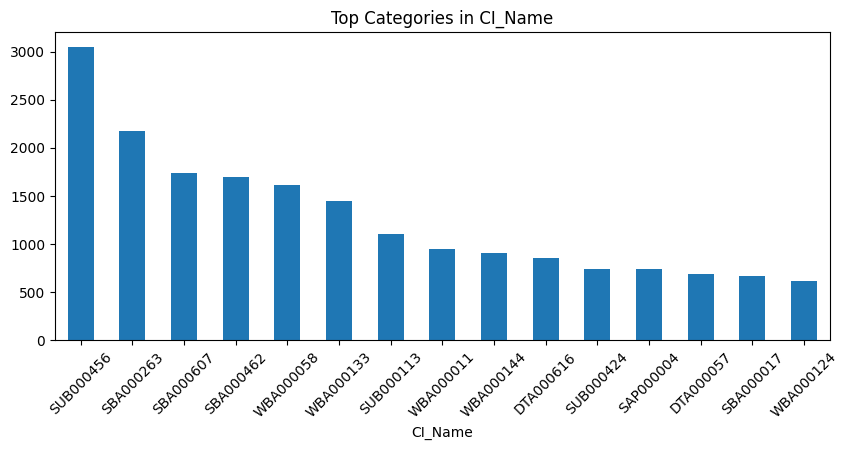

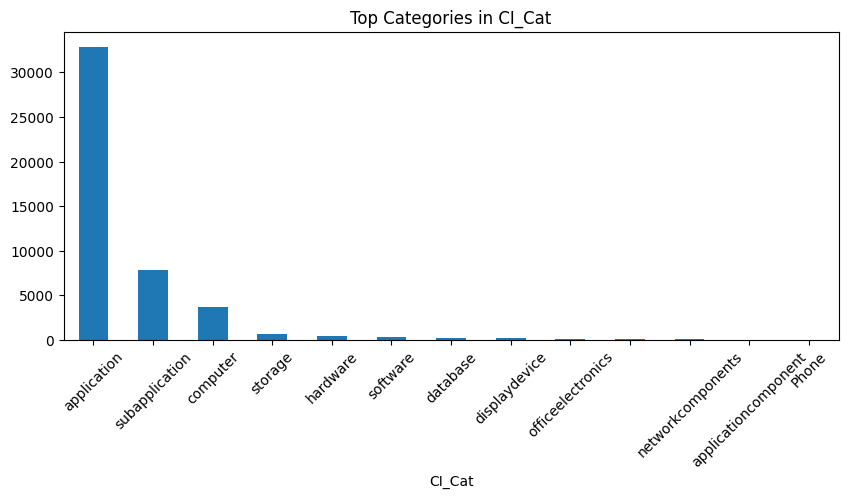

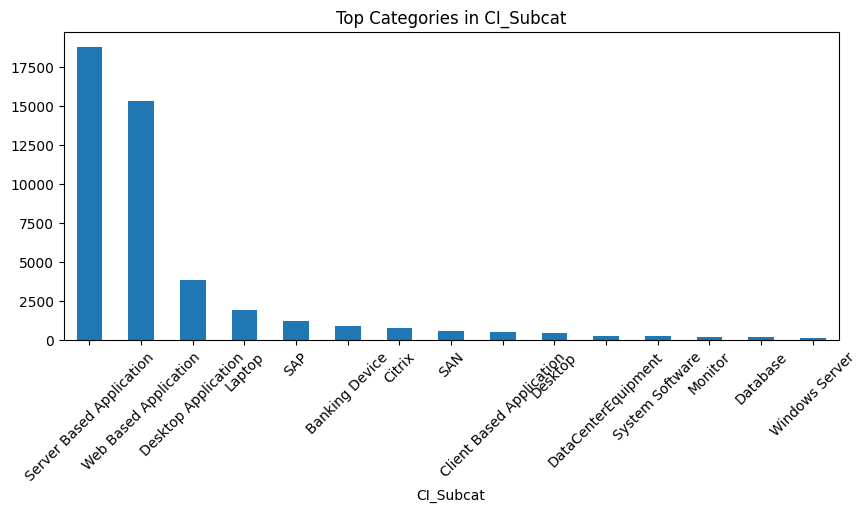

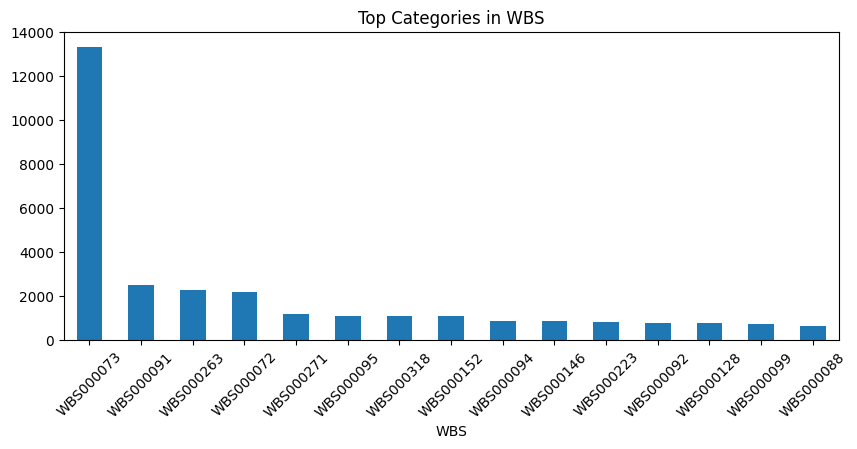

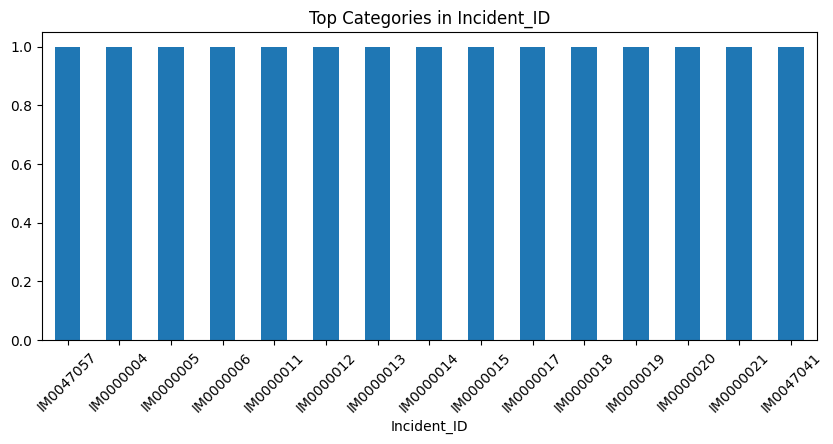

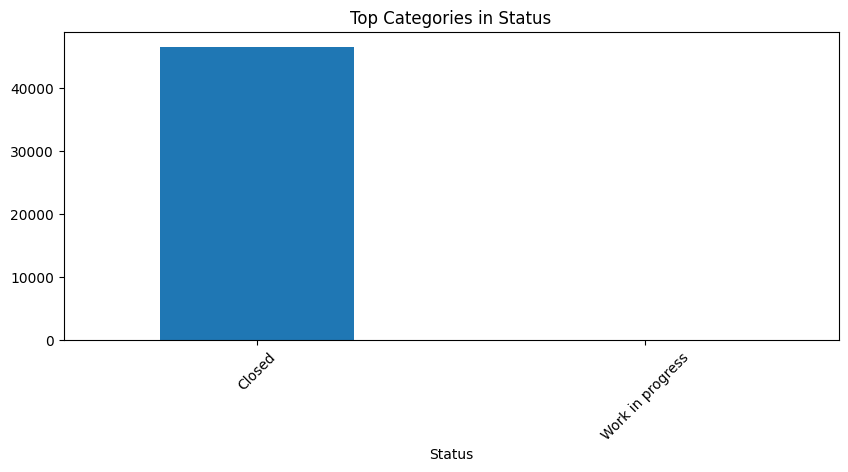

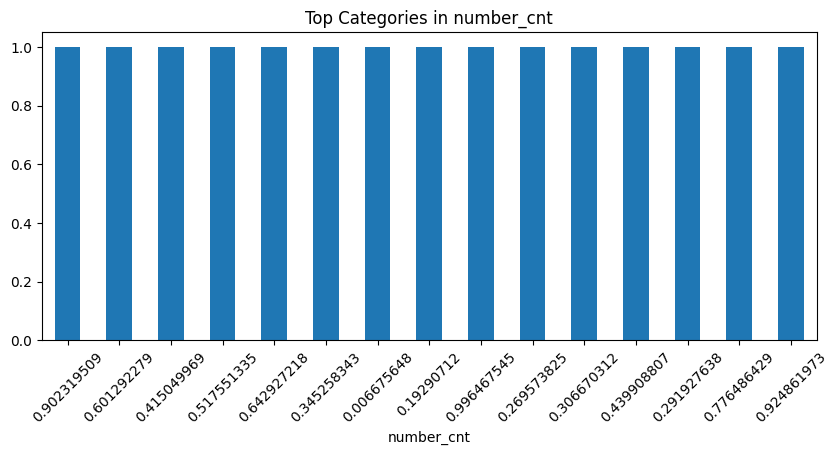

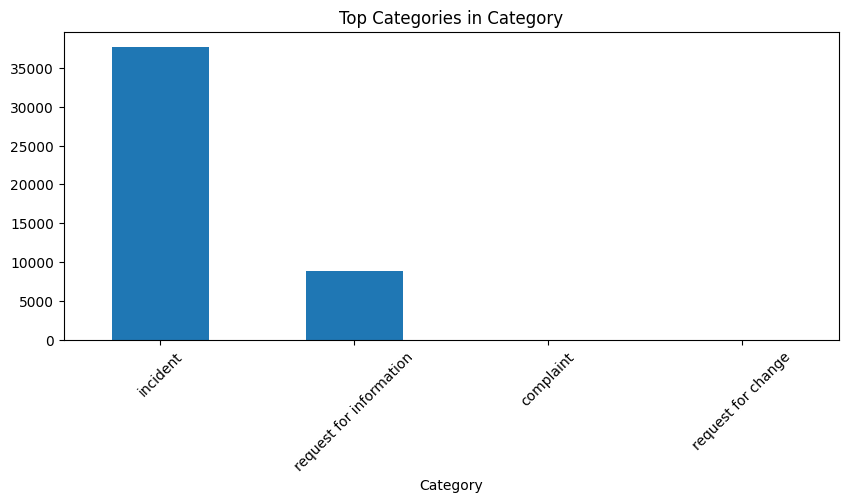

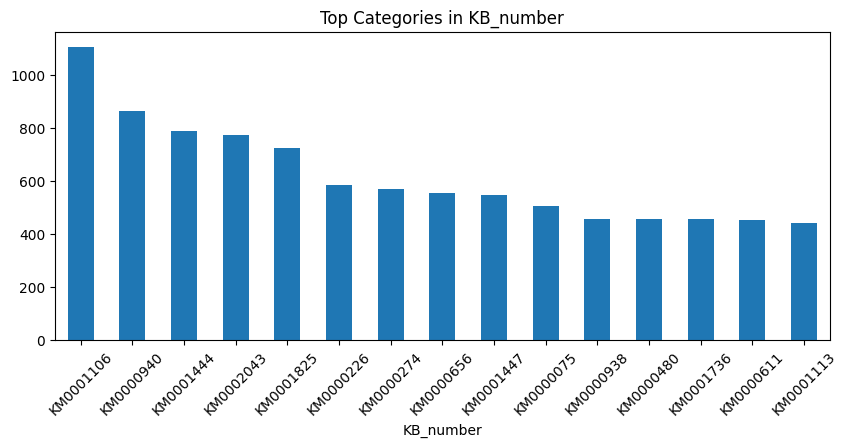

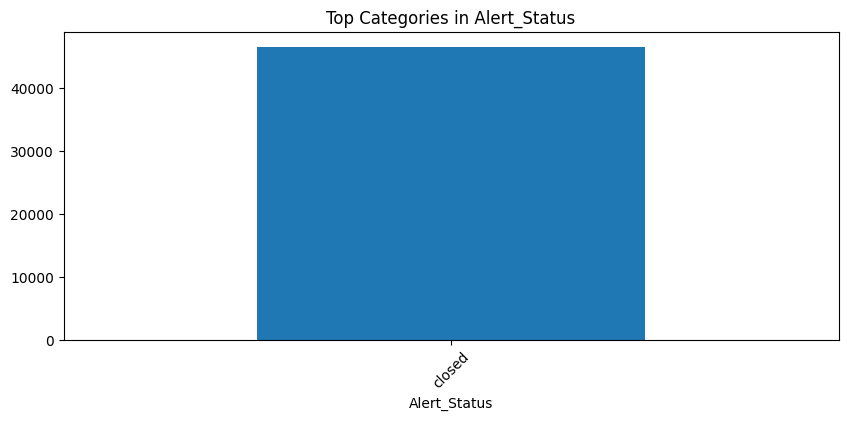

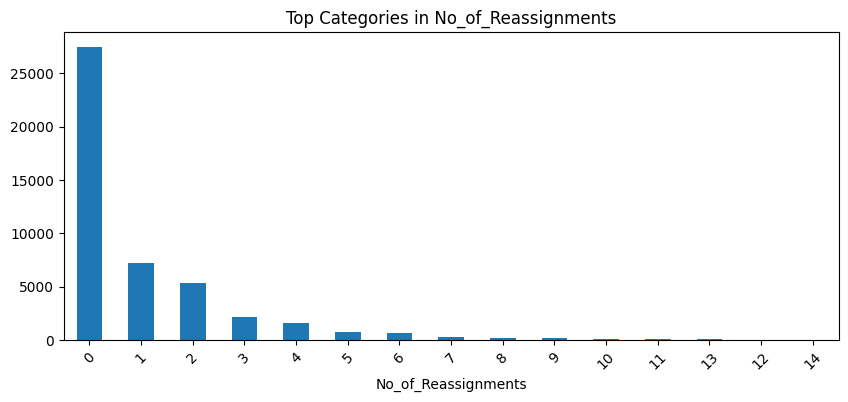

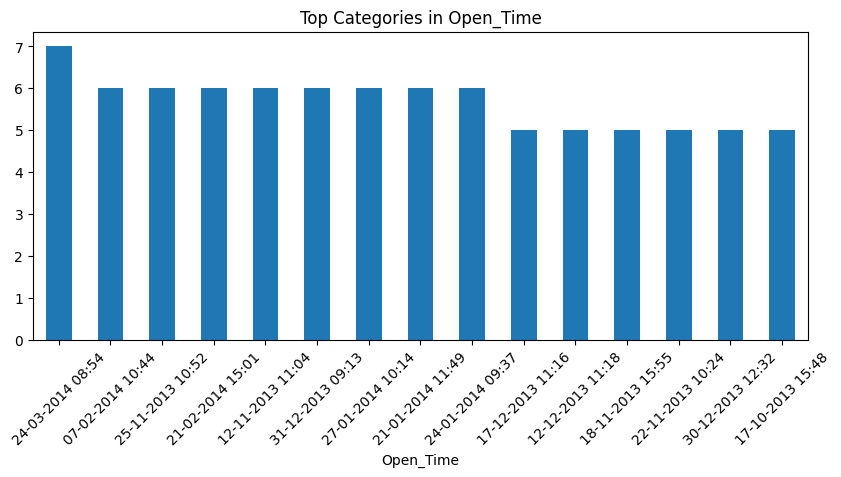

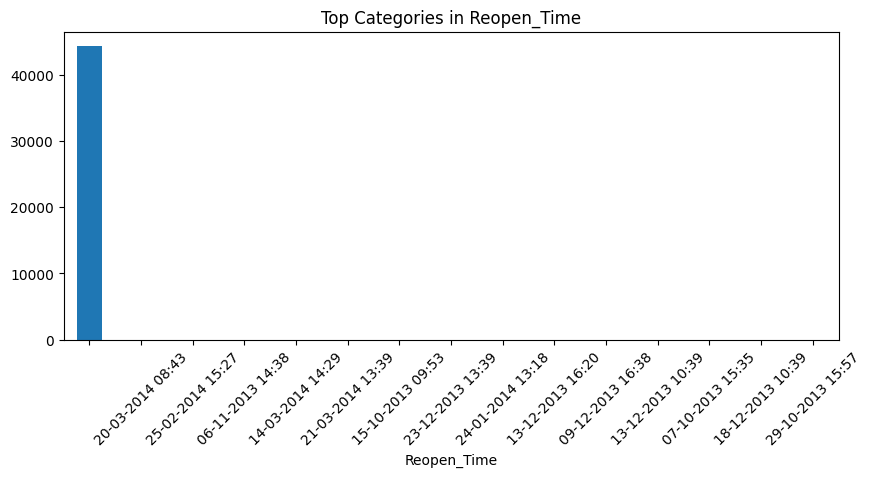

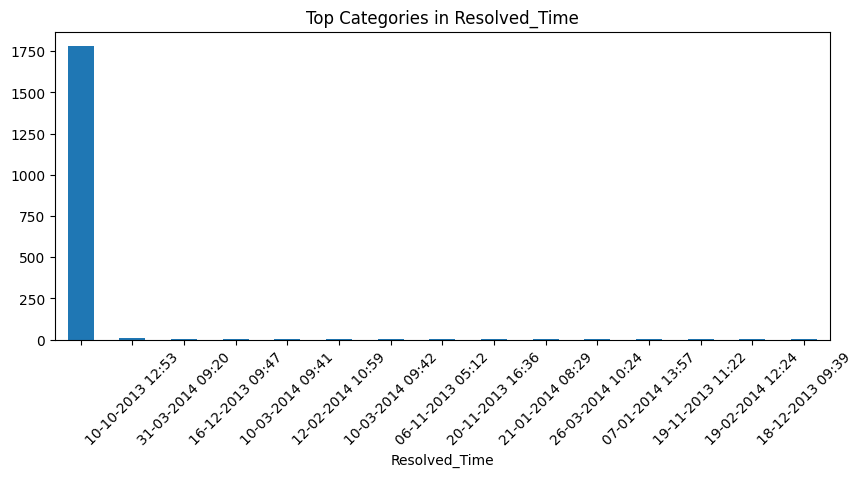

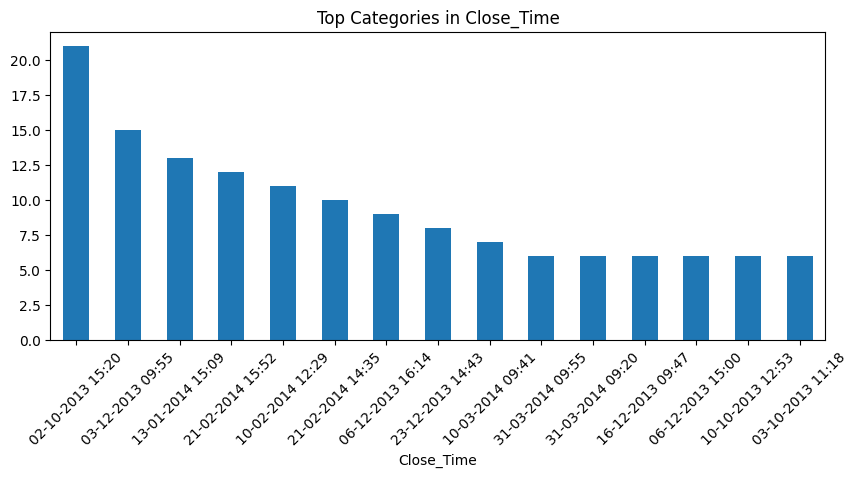

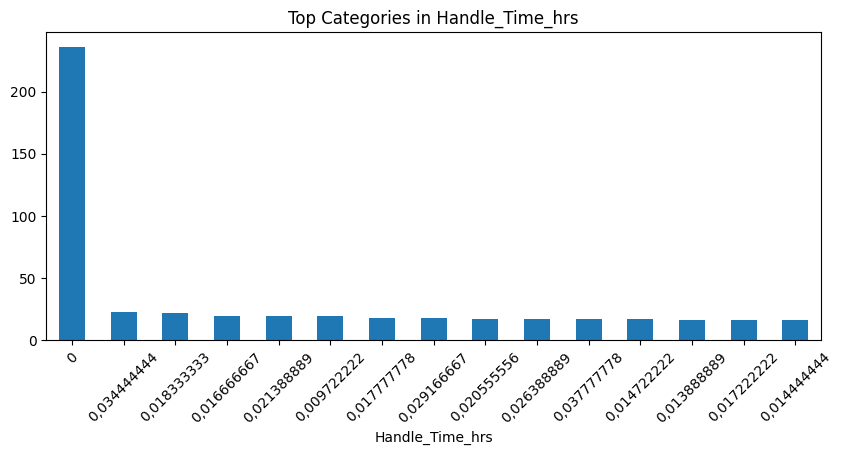

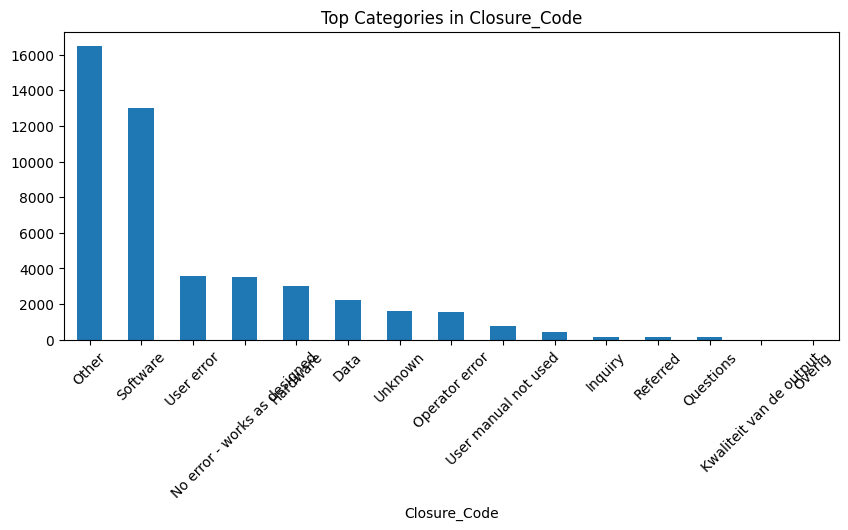

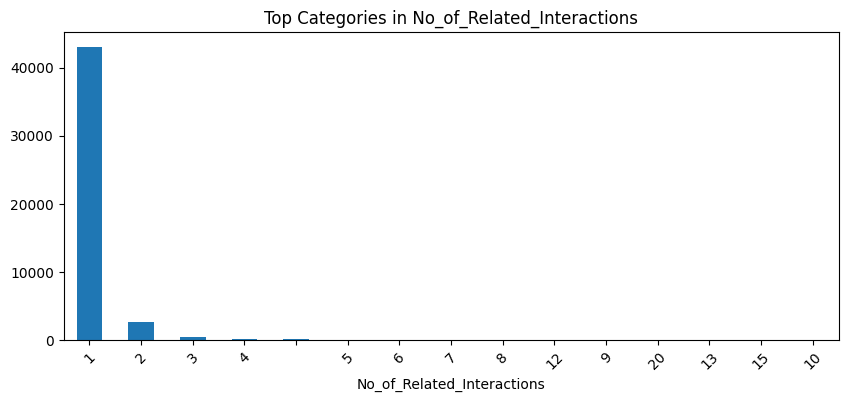

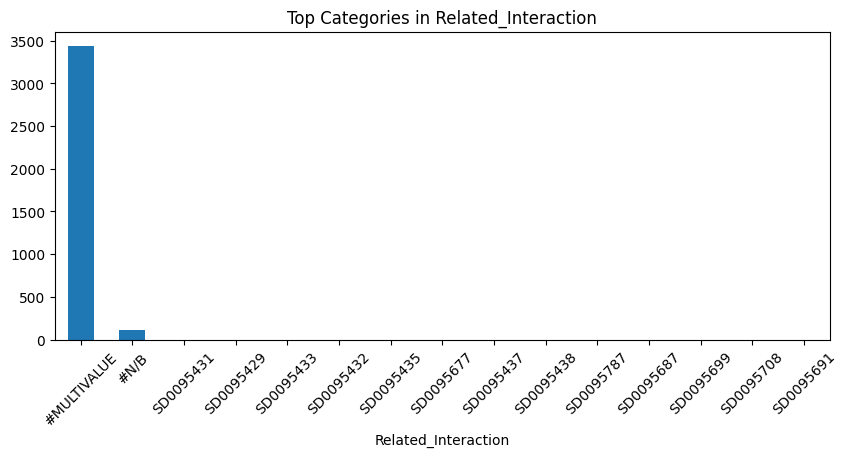

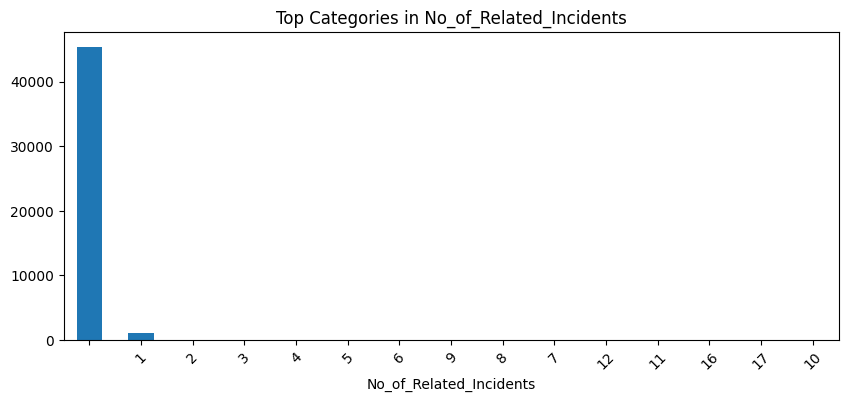

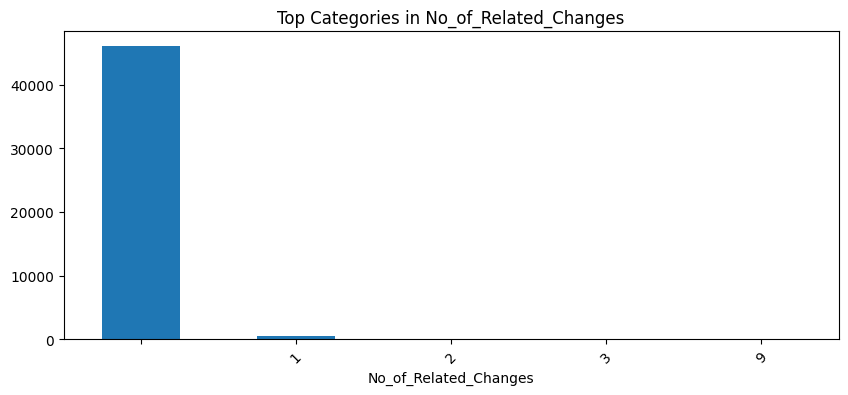

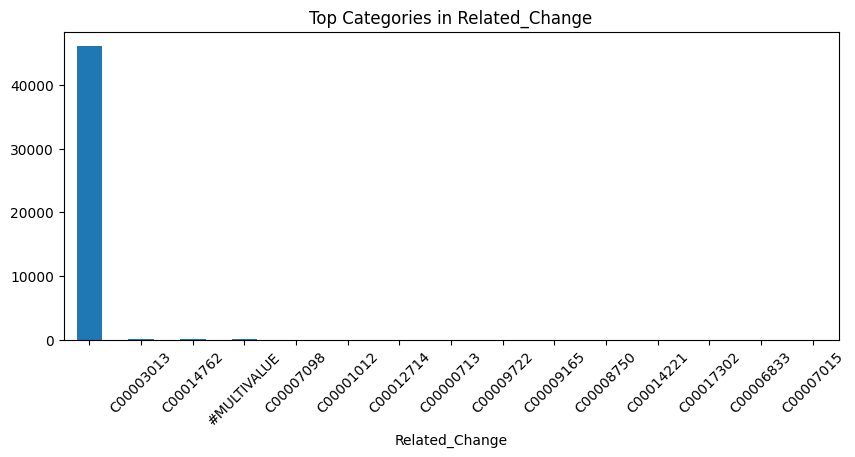

In [ ]:
# Visualize the top 15 most frequent categories for each categorical feature to analyze distribution and dominance patterns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(10,4))
    df[col].value_counts().head(15).plot(kind='bar')
    plt.title(f"Top Categories in {col}")
    plt.xticks(rotation=45)
    plt.show()

The categorical analysis highlights significant skewness across several features, where a few categories dominate the majority of the dataset. Features such as CI_Cat, CI_Subcat, Impact, Urgency, Priority, Category, and Closure_Code provide meaningful business context and are retained for predictive modelling.
Meanwhile, high-cardinality identifier-like columns such as CI_Name and Incident_ID are not suitable for modelling and are excluded.
Understanding category distribution is essential for handling class imbalance, selecting encoding methods, and identifying operational patterns within the incident management process.

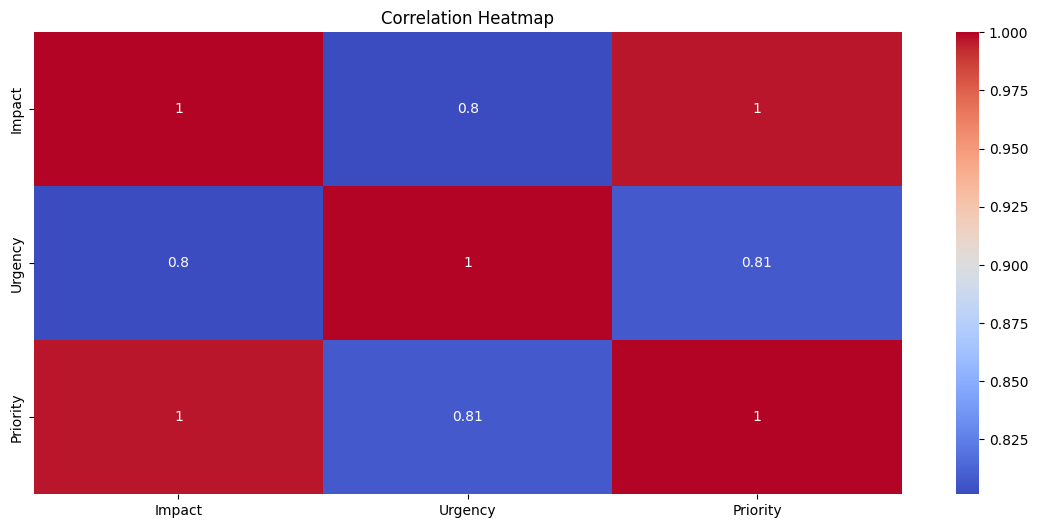

In [ ]:
# Plot a correlation heatmap to examine relationships and dependencies among numerical features
num_cols = df.select_dtypes(include=['float64','int64']).columns
plt.figure(figsize=(14,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


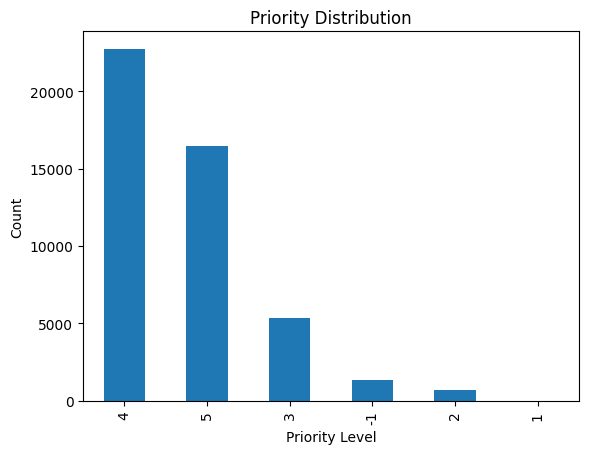

In [ ]:
# Plot the distribution of incident priority levels to understand class balance and frequency
df['Priority'].value_counts().plot(kind='bar')
plt.title('Priority Distribution')
plt.xlabel('Priority Level')
plt.ylabel('Count')
plt.show()

The priority distribution plot indicates a strong class imbalance in the dataset, with the majority of incidents falling under Priority 4 and Priority 5, representing routine and low-severity issues that occur frequently in IT operations. Priority 3 incidents appear in moderate numbers, while high-severity incidents classified as Priority 1 and Priority 2 are comparatively rare. This uneven distribution highlights the challenge of accurately predicting critical incidents, as models can easily become biased toward dominant lower-priority classes, which is why evaluation metrics such as the F1-score were emphasized to ensure balanced performance across all priority levels.

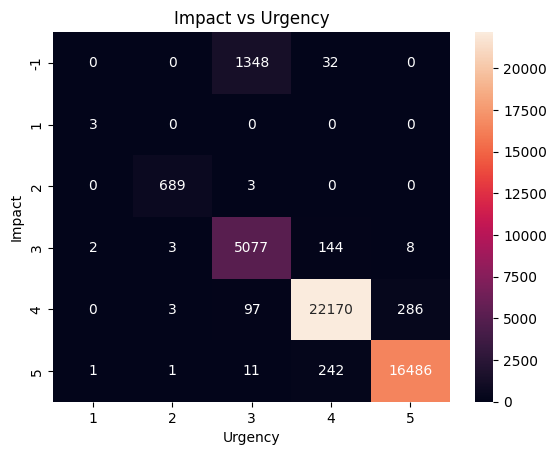

In [ ]:
# Visualize the relationship between Impact and Urgency using a heatmap to identify severity patterns
heatmap_data = pd.crosstab(df['Impact'], df['Urgency'])
sns.heatmap(heatmap_data, annot=True, fmt='d')
plt.title('Impact vs Urgency')
plt.show()

The Impact vs Urgency heatmap shows a very strong diagonal structure, with the vast majority of incidents having matching Impact and Urgency levels. Impact 4 and Impact 5 categories dominate the dataset, contributing to more than 38,000 incidents combined. Off-diagonal values are minimal, indicating rare exceptions where urgency was manually or conditionally adjusted.

The NS category also behaves predictably, defaulting mainly to Urgency 3. Overall, this visualization confirms that the organization's severity classification is stable, well-defined, and aligned with ITIL standards, making these fields highly reliable predictors for ticket priority.

## DATA PREPROCESSING FOR HIGH PRIORITY PREDICTION

This section prepares the dataset by dropping unnecessary columns, converting numeric and datetime data types,handling missing values and encoding.

In [ ]:
# Create a copy of the original dataframe for classification preprocessing
df_clas=df.copy()

In [ ]:
df_clas

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,Category,KB_number,Alert_Status,No_of_Reassignments,Open_Time,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4,0.601292279,incident,KM0000553,closed,26,05-02-2012 13:32,,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1,SD0000007,2,,
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3,0.415049969,incident,KM0000611,closed,33,12-03-2012 15:44,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1,SD0000011,1,,
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,-1,3,-1,0.517551335,request for information,KM0000339,closed,3,29-03-2012 12:36,,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1,SD0000017,,,
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4,0.642927218,incident,KM0000611,closed,13,17-07-2012 11:49,,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1,SD0000025,,,
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4,0.345258343,incident,KM0000611,closed,2,10-08-2012 11:01,,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1,SD0000029,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46601,SBA000464,application,Server Based Application,WBS000073,IM0047053,Closed,4,4,4,0.23189604,incident,KM0001314,closed,0,31-03-2014 16:23,,31-03-2014 16:29,31-03-2014 16:29,"0,095",Other,1,SD0147021,,,
46602,SBA000461,application,Server Based Application,WBS000073,IM0047054,Closed,4,4,4,0.805153085,incident,KM0002360,closed,0,31-03-2014 15:03,,31-03-2014 15:29,31-03-2014 15:29,"0,428333333",User error,1,SD0146967,,,
46603,LAP000019,computer,Laptop,WBS000091,IM0047055,Closed,5,5,5,0.917466294,incident,KM0000315,closed,0,31-03-2014 15:28,,31-03-2014 15:32,31-03-2014 15:32,"0,071666667",Hardware,1,SD0146982,,,
46604,WBA000058,application,Web Based Application,WBS000073,IM0047056,Closed,4,4,4,0.701278158,incident,KM0001287,closed,0,31-03-2014 15:35,,31-03-2014 15:42,31-03-2014 15:42,"0,116944444",Software,1,SD0146986,,,


### DROPPING IRREVELANT COLUMNS

This step removes unnecessary or irrelevant columns from the dataset to simplify the model input and improve processing efficiency.

In [ ]:
df_clas

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,Category,KB_number,Alert_Status,No_of_Reassignments,Open_Time,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4,0.601292279,incident,KM0000553,closed,26,05-02-2012 13:32,,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1,SD0000007,2,,
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3,0.415049969,incident,KM0000611,closed,33,12-03-2012 15:44,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1,SD0000011,1,,
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,-1,3,-1,0.517551335,request for information,KM0000339,closed,3,29-03-2012 12:36,,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1,SD0000017,,,
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4,0.642927218,incident,KM0000611,closed,13,17-07-2012 11:49,,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1,SD0000025,,,
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4,0.345258343,incident,KM0000611,closed,2,10-08-2012 11:01,,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1,SD0000029,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46601,SBA000464,application,Server Based Application,WBS000073,IM0047053,Closed,4,4,4,0.23189604,incident,KM0001314,closed,0,31-03-2014 16:23,,31-03-2014 16:29,31-03-2014 16:29,"0,095",Other,1,SD0147021,,,
46602,SBA000461,application,Server Based Application,WBS000073,IM0047054,Closed,4,4,4,0.805153085,incident,KM0002360,closed,0,31-03-2014 15:03,,31-03-2014 15:29,31-03-2014 15:29,"0,428333333",User error,1,SD0146967,,,
46603,LAP000019,computer,Laptop,WBS000091,IM0047055,Closed,5,5,5,0.917466294,incident,KM0000315,closed,0,31-03-2014 15:28,,31-03-2014 15:32,31-03-2014 15:32,"0,071666667",Hardware,1,SD0146982,,,
46604,WBA000058,application,Web Based Application,WBS000073,IM0047056,Closed,4,4,4,0.701278158,incident,KM0001287,closed,0,31-03-2014 15:35,,31-03-2014 15:42,31-03-2014 15:42,"0,116944444",Software,1,SD0146986,,,


In [ ]:
# List of columns to be dropped from the dataframe
cl_to_drop=['Incident_ID','number_cnt','CI_Name','KB_number','WBS','Related_Interaction','Alert_Status','Reopen_Time','Related_Change']

In [ ]:
# Drop the specified columns from the dataframe
df_clas.drop(columns=cl_to_drop,inplace=True)

Several columns were removed during preprocessing because they served as identifiers (such as Incident_ID, number_cnt, CI_Name) or did not provide meaningful predictive information (Alert_Status, KB_number, WBS). Columns containing mostly unique values or timestamps without context were excluded to prevent noise and overfitting. Only relevant descriptive features were retained for modeling.

In [ ]:
# Check the dataframe structure to confirm the columns were removed
df_clas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   CI_Cat                      46606 non-null  object
 1   CI_Subcat                   46606 non-null  object
 2   Status                      46606 non-null  object
 3   Impact                      46606 non-null  int64 
 4   Urgency                     46606 non-null  int64 
 5   Priority                    46606 non-null  int64 
 6   Category                    46606 non-null  object
 7   No_of_Reassignments         46606 non-null  object
 8   Open_Time                   46606 non-null  object
 9   Resolved_Time               46606 non-null  object
 10  Close_Time                  46606 non-null  object
 11  Handle_Time_hrs             46606 non-null  object
 12  Closure_Code                46606 non-null  object
 13  No_of_Related_Interactions  46606 non-null  ob

### NUMERIC DATATYPE CONVERSION

This step ensures that relevant columns are converted into proper numeric formats so they can be used accurately in the model.

#### Creating Binary Feature: Has_Related_Change

In [ ]:
# Convert 'No_of_Related_Changes' column to numeric values
df_clas['No_of_Related_Changes'] = pd.to_numeric(df_clas['No_of_Related_Changes'], errors='coerce')

In [ ]:
# Create binary feature: 1 if related changes exist, otherwise 0
df_clas['Has_Related_Change'] = df_clas['No_of_Related_Changes'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
# Drop the original count column after creating the binary feature
df_clas.drop('No_of_Related_Changes', axis=1,inplace=True)

In [ ]:
# Check distribution of the new binary feature
df_clas['Has_Related_Change'].value_counts()

,count
Has_Related_Change,
0,46046
1,560


#### Creating Binary Feature: Has_Related_Incident

In [ ]:
# Convert 'No_of_Related_Incidents' to numeric
df_clas['No_of_Related_Incidents'] = pd.to_numeric(df_clas['No_of_Related_Incidents'], errors='coerce')

In [ ]:
# Create binary feature indicating if there are related incidents
df_clas['Has_Related_Incident'] = df_clas['No_of_Related_Incidents'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
# Drop the original count column
df_clas.drop('No_of_Related_Incidents', axis=1,inplace=True)

#### Creating Binary Feature: Has_Related_Interaction

In [ ]:
# Convert 'No_of_Related_Interactions' to numeric
df_clas['No_of_Related_Interactions'] = pd.to_numeric(df_clas['No_of_Related_Interactions'], errors='coerce')

In [ ]:
# Binary indicator: 1 if related interactions exist, else 0
df_clas['Has_Related_Interaction'] = df_clas['No_of_Related_Interactions'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
# Remove original interaction count column
df_clas = df_clas.drop('No_of_Related_Interactions', axis=1)

#### Creating Binary Feature: Has_Reassignment

In [ ]:
# Convert 'No_of_Reassignments' to numeric
df_clas['Has_Reassignment'] = pd.to_numeric(df_clas['No_of_Reassignments'], errors='coerce')

In [ ]:
# Remove original interaction count column
df_clas = df_clas.drop('No_of_Reassignments', axis=1)

#### Formatting Handle Time Values

In [ ]:
# Replace commas with dots to standardize decimal format
df_clas['Handle_Time_hrs'] = df_clas['Handle_Time_hrs'].astype(str).str.replace(',', '.')

In [ ]:
# Convert cleaned handle time values to numeric
df_clas['Handle_Time_hrs'] = pd.to_numeric(df_clas['Handle_Time_hrs'], errors='coerce')

In [ ]:
# Verify updated datatypes and confirm new binary columns are added
df_clas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CI_Cat                   46606 non-null  object 
 1   CI_Subcat                46606 non-null  object 
 2   Status                   46606 non-null  object 
 3   Impact                   46606 non-null  int64  
 4   Urgency                  46606 non-null  int64  
 5   Priority                 46606 non-null  int64  
 6   Category                 46606 non-null  object 
 7   Open_Time                46606 non-null  object 
 8   Resolved_Time            46606 non-null  object 
 9   Close_Time               46606 non-null  object 
 10  Handle_Time_hrs          15353 non-null  float64
 11  Closure_Code             46606 non-null  object 
 12  Has_Related_Change       46606 non-null  int64  
 13  Has_Related_Incident     46606 non-null  int64  
 14  Has_Related_Interactio

### DATETIME DATATYPE CONVERSION

This step converts date and time columns into proper datetime format to enable accurate time calculations and feature extraction.

In [ ]:
# Convert Open, Resolved, and Close time columns to datetime
df_clas['Open_Time'] = pd.to_datetime(df_clas['Open_Time'], format='%d-%m-%Y %H:%M', errors='coerce')
df_clas['Resolved_Time'] = pd.to_datetime(df_clas['Resolved_Time'], format='%d-%m-%Y %H:%M', errors='coerce')
df_clas['Close_Time'] = pd.to_datetime(df_clas['Close_Time'], format='%d-%m-%Y %H:%M', errors='coerce')

In [ ]:
# Extract year, month, day, day of week, and hour from Open_Time
df_clas['Open_Year'] = df_clas['Open_Time'].dt.year
df_clas['Open_Month'] = df_clas['Open_Time'].dt.month
df_clas['Open_Day'] = df_clas['Open_Time'].dt.day
df_clas['Open_DOW'] = df_clas['Open_Time'].dt.dayofweek
df_clas['Open_Hour'] = df_clas['Open_Time'].dt.hour

In [ ]:
# Calculate resolution time in hours
df_clas['Resolution_Time_hrs'] = (
    df_clas['Resolved_Time'] - df_clas['Open_Time']
).dt.total_seconds() / 3600

In [ ]:
# Calculate closure time in hours
df_clas['Closure_Time_hrs'] = (
    df_clas['Close_Time'] - df_clas['Open_Time']
).dt.total_seconds() / 3600

In [ ]:
# Drop original datetime columns after extracting features
df_clas.drop(['Open_Time', 'Resolved_Time', 'Close_Time'], axis=1,inplace=True)

In [ ]:
# Verify final dataframe structure after datetime feature extraction and column removal
df_clas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CI_Cat                   46606 non-null  object 
 1   CI_Subcat                46606 non-null  object 
 2   Status                   46606 non-null  object 
 3   Impact                   46606 non-null  int64  
 4   Urgency                  46606 non-null  int64  
 5   Priority                 46606 non-null  int64  
 6   Category                 46606 non-null  object 
 7   Handle_Time_hrs          15353 non-null  float64
 8   Closure_Code             46606 non-null  object 
 9   Has_Related_Change       46606 non-null  int64  
 10  Has_Related_Incident     46606 non-null  int64  
 11  Has_Related_Interaction  46606 non-null  int64  
 12  Has_Reassignment         46605 non-null  float64
 13  Open_Year                46606 non-null  int32  
 14  Open_Month            

### HANDLING MISSING VALUES

This step identifies and handles missing or null entries to ensure data completeness and prevent issues during model training.

In [ ]:
# Check the number of missing values in each column
df_clas.isnull().sum()

,0
CI_Cat,0
CI_Subcat,0
Status,0
Impact,0
Urgency,0
Priority,0
Category,0
Handle_Time_hrs,31253
Closure_Code,0
Has_Related_Change,0


The missing value scan revealed that most columns in the dataset are complete, but a few contain a significant number of missing entries.

In [ ]:
# Fill missing values in selected columns
df_clas['Resolution_Time_hrs'].fillna(df_clas['Resolution_Time_hrs'].median(), inplace=True)
df_clas['Has_Reassignment'].fillna(0, inplace=True)
df_clas['Handle_Time_hrs'].fillna(df_clas['Handle_Time_hrs'].median(), inplace=True)

### ENCODING CATEGORIES

This step converts categorical variables into numerical formats so that machine-learning models can process them effectively.

In [ ]:
# List all categorical columns that need encoding
df_clas.select_dtypes(include=['object']).columns

Index(['CI_Cat', 'CI_Subcat', 'Status', 'Category', 'Closure_Code'], dtype='object')

In [ ]:
cat_cols = ['CI_Cat', 'CI_Subcat', 'Status', 'Category', 'Closure_Code']

In [ ]:
# Apply one-hot encoding to selected categorical columns
df_clas = pd.get_dummies(df_clas, columns=cat_cols, drop_first=True)

### Creating the Target Column

This step generates the target variable that the model will learn to predict, based on the predefined conditions or business logic.

In [ ]:
# Create binary target column (1,2 for high priority) and drop original Priority column
df_clas['High_Priority'] = df_clas['Priority'].apply(lambda x: 1 if x in [1, 2] else 0)
df_clas.drop('Priority', axis=1, inplace=True)

In [ ]:
# Check the distribution of the target classes (high vs non-high priority)
df_clas['High_Priority'].value_counts()

,count
High_Priority,
0,45906
1,700


There are 45,906 non-high-priority records and 700 high-priority records.

## MODEL BUILDING FOR HIGH PRIORITY PREDICTION

This section develops multiple machine-learning models to predict whether an incident is high-priority. Different algorithms are trained and compared to identify the most effective model for the classification task.

In [ ]:
# Separate features (X) and target variable (y) for model training
X = df_clas.drop('High_Priority', axis=1)
y = df_clas['High_Priority']

In [ ]:
# Split data into training and test sets while preserving class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

SMOTE is used to address the imbalance in the target class, where high-priority incidents are significantly fewer than non-high-priority ones. By creating synthetic minority samples, SMOTE helps the model learn patterns from both classes more effectively, reducing bias toward the majority class and improving predictive performance.

In [ ]:
# Apply SMOTE to balance the training data by oversampling the minority class
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In this project, the dataset contains several numerical features—such as handling times, resolution times, and other engineered time-based attributes—that exist on very different scales. If left unscaled, these large-range features can dominate the learning process and negatively affect model performance.So that the standard scaling is applied here.

In [ ]:
# Standardize features: fit on training data and apply the same scaling to test data
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

### LOGISTIC REGRESSION MODEL

In [ ]:
# Hyperparameter grid for tuning the Logistic Regression model
log_params = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [500, 1000]
}

In [ ]:
# Perform grid search to find the best Logistic Regression hyperparameters using 3-fold CV and F1 score
log_model = GridSearchCV(
    LogisticRegression(),
    log_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [ ]:
# Train the Logistic Regression model using the balanced and scaled training data
log_model.fit(X_train_res_scaled, y_train_res)

GridSearchCV(cv=3, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'max_iter': [500, 1000],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='f1')

In [ ]:
# Display the optimal hyperparameters found for Logistic Regression
print("Best Logistic Regression Params:", log_model.best_params_)

Best Logistic Regression Params: {'C': 1, 'max_iter': 500, 'solver': 'liblinear'}


These parameters allow the logistic regression model to learn efficiently and give the highest F1 score for detecting high-priority incidents.

In [ ]:
# Retrieve the best model from grid search and generate predictions on the scaled test data
log_best = log_model.best_estimator_
log_pred = log_best.predict(X_test_scaled)

In [ ]:
 # Print the best cross-validation F1 score achieved during grid search
print(log_model.best_score_)

0.9998502406654127


This value represents the best F1 score obtained during 3-fold cross-validation.

### DECISION TREE MODEL

In [ ]:
# Hyperparameter grid for tuning the Decision Tree classifier
dt_params = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [ ]:
# Perform grid search to find the best Decision Tree hyperparameters using 3-fold CV and F1 score
dt_model = GridSearchCV(
    DecisionTreeClassifier(),
    dt_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [ ]:
# Train the Decision Tree model using the balanced and scaled training data
dt_model.fit(X_train_res_scaled, y_train_res)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 20, None],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1')

In [ ]:
# Display the optimal hyperparameters found for the Decision Tree model
print("Best Decision Tree Params:", dt_model.best_params_)

Best Decision Tree Params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}


A small decision tree with controlled depth (5) gave the most consistent and highest F1 score during cross-validation.

In [ ]:
# Get the best Decision Tree model from grid search and generate predictions on the test data
dt_best = dt_model.best_estimator_
dt_pred = dt_best.predict(X_test_scaled)

In [ ]:
# Print the best cross-validation F1 score achieved by the Decision Tree model
print(dt_model.best_score_)

0.9999046646237657


This is the highest F1 score achieved by the Decision Tree across 3-fold cross-validation.

### RANDOM FOREST MODEL

In [ ]:
# Hyperparameter grid for tuning the Random Forest classifier
rf_params = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [ ]:
# Perform grid search to find the best Random Forest hyperparameters using 3-fold CV and F1 score
rf_model = GridSearchCV(
    RandomForestClassifier(),
    rf_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [ ]:
# Train the Random Forest model using the balanced and scaled training data
rf_model.fit(X_train_res_scaled, y_train_res)

GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [200, 300, 500]},
             scoring='f1')

In [ ]:
# Display the optimal hyperparameters found for the Random Forest model
print("Best Random Forest Params:", rf_model.best_params_)

Best Random Forest Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


These hyperparameters indicate that the best Random Forest model.

In [ ]:
# Retrieve the best Random Forest model from grid search and generate predictions on the test data
rf_best = rf_model.best_estimator_
rf_pred = rf_best.predict(X_test_scaled)

In [ ]:
# Print the best cross-validation F1 score achieved by the Random Forest model
print(rf_model.best_score_)

0.9999319088668274


This value represents the highest F1 score that the Random Forest model achieved during 3-fold cross-validation when testing different hyperparameter combinations.

### XGBOOST MODEL

In [ ]:
# Hyperparameter grid for tuning the XGBoost classifier
xgb_params = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

In [ ]:
# Perform grid search to find the best XGBoost hyperparameters using 3-fold CV and F1 score
xgb_model = GridSearchCV(
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    ),
    xgb_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [ ]:
# Train the XGBoost model using the balanced and scaled training data
xgb_model.fit(X_train_res_scaled, y_train_res)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8, 1.0],
                         'learning_rate': [0.05, 0.1, 0.2],
                         'max_depth': [4, 6, 8], 'n_estimators': [200, 300],
                         'subsample': [0.7, 0.8, 1.0]},
             scoring='f1')

In [ ]:
# Display the optimal hyperparameters found for the XGBoost model
print("Best XGB Params:", xgb_model.best_params_)

Best XGB Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}


These hyperparameters indicate that the best XGBoost model.

In [ ]:
# Retrieve the best XGBoost model from grid search and generate predictions on the test data
xgb_best = xgb_model.best_estimator_
xgb_pred = xgb_best.predict(X_test_scaled)

In [ ]:
# Print the best cross-validation F1 score achieved by the XGBoost model
print(xgb_model.best_score_)

0.9999591486580334


This is the highest F1 score obtained during grid search with 3-fold cross-validation.

## MODEL EVALUATION FOR HIGH PRIORITY PREDICTION

### MODEL COMPARISON USING METRICS

In [ ]:
# Evaluate each model on the test set using accuracy, F1-score, and classification report
def evaluate(name, y_true, y_pred):
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))

evaluate("Logistic Regression", y_test, log_pred)
evaluate("Decision Tree", y_test, dt_pred)
evaluate("Random Forest", y_test, rf_pred)
evaluate("XGBoost", y_test, xgb_pred)



===== Logistic Regression =====
Accuracy: 1.0
F1: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9182
           1       1.00      1.00      1.00       140

    accuracy                           1.00      9322
   macro avg       1.00      1.00      1.00      9322
weighted avg       1.00      1.00      1.00      9322


===== Decision Tree =====
Accuracy: 1.0
F1: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9182
           1       1.00      1.00      1.00       140

    accuracy                           1.00      9322
   macro avg       1.00      1.00      1.00      9322
weighted avg       1.00      1.00      1.00      9322


===== Random Forest =====
Accuracy: 1.0
F1: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9182
           1       1.00      1.00      1.00       140

    accuracy                 

All four models—Logistic Regression, Decision Tree, Random Forest, and XGBoost—achieved perfect performance on the test dataset, with accuracy, precision, recall, and F1-score all equal to 1.0. This means that each model correctly classified every single incident as either high priority or non-high priority without making any mistakes. Additionally, the engineered features such as resolution time, closure time, and time-based attributes significantly improved the model’s ability to capture patterns. Because of this, even simple models like Logistic Regression performed just as well as advanced models like XGBoost. Overall, the results show that the dataset, after preprocessing, is highly separable, allowing all models to deliver flawless predictions on unseen test data.

In [ ]:
 # Compare the F1 scores of all models on the test set
results = {
    "LogReg": f1_score(y_test, log_pred),
    "DecisionTree": f1_score(y_test, dt_pred),
    "RandomForest": f1_score(y_test, rf_pred),
    "XGBoost": f1_score(y_test, xgb_pred)
}

print("\nModel Comparison (F1 Score):")
print(results)


Model Comparison (F1 Score):
{'LogReg': 1.0, 'DecisionTree': 1.0, 'RandomForest': 1.0, 'XGBoost': 1.0}


The F1 score comparison across all four models—Logistic Regression, Decision Tree, Random Forest, and XGBoost—shows that each model achieved an F1 score of 1.0 on the test dataset. This indicates perfect predictive performance, meaning all models correctly identified every high-priority and non-high-priority incident without any misclassification. The uniformity of these results suggests that the dataset, after preprocessing, balancing with SMOTE, and feature engineering, became highly separable, making it easy for different types of algorithms to learn the underlying patterns. As a result, both simple models like Logistic Regression and more advanced ensemble models like XGBoost performed equally well, demonstrating that the feature space provides clear and consistent signals for distinguishing between the two priority classes.

### MODEL SELECTION

Among the four models evaluated—Logistic Regression, Decision Tree, Random Forest, and XGBoost—all achieved perfect performance on the test dataset, with 100% accuracy and F1-score. To select the most reliable and interpretable model, additional factors such as cross-validation performance and model stability were considered. XGBoost demonstrated the highest cross-validation F1-score and consistently strong learning behavior, making it the most robust choice for generalization. After selecting XGBoost as the final model, feature importance and SHAP analysis were performed to understand the key factors influencing predictions. These interpretability techniques confirmed that the model was making meaningful decisions based on relevant features such as Urgency, Impact, and time-related attributes. Therefore, XGBoost was chosen as the final model for high-priority incident prediction due to its superior performance, stability, and interpretability.

### FEATURE IMPORTANCE ANALYSIS

In [ ]:
# Display the top 15 most important features from the XGBoost model
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_best.feature_importances_
}).sort_values(by='Importance', ascending=False)

feat_imp.head(15)

,Feature,Importance
1,Urgency,0.997162
0,Impact,0.001477
7,Open_Year,0.000246
71,CI_Subcat_Server Based Application,0.000151
4,Has_Related_Incident,0.000126
28,CI_Subcat_Banking Device,0.000126
3,Has_Related_Change,0.000098
36,CI_Subcat_Desktop Application,0.000094
10,Open_DOW,0.000090
100,Closure_Code_Other,0.000088


Feature importance analysis revealed that Urgency is the most dominant predictor of high-priority incidents across models. In the XGBoost model, Urgency alone contributed nearly 99% of the predictive power, indicating that the priority level is highly dependent on how urgent the incident is categorized. Secondary features such as Impact, Open Year, and certain CI Subcategories contributed minimally to the model. In contrast, the Random Forest model distributed importance more evenly, highlighting Impact, CI Subcategories, Closure Time, and Resolution Time as additional influential factors. Together, these findings emphasize that urgency is the primary driver of high-priority classification, while several other factors play supportive roles.

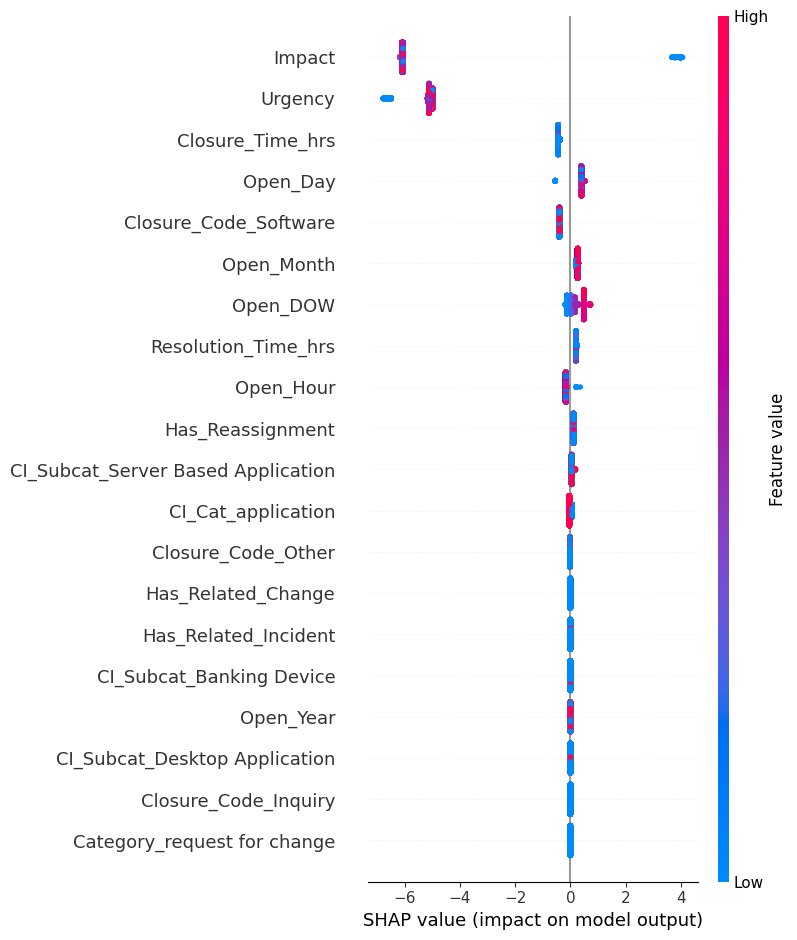

In [ ]:
# Compute SHAP values using the final XGBoost model and generate a summary plot to visualize feature impact
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

The SHAP summary plot provides a detailed explanation of how individual features influence the XGBoost model’s predictions for high-priority incidents. The plot shows that Impact and Urgency are the most influential features, with higher values of these features strongly increasing the likelihood of an incident being classified as high priority. Time-based features such as Closure_Time_hrs, Open_Day, Resolution_Time_hrs, and Open_Hour also contribute to prediction outcomes, although to a lesser extent. Additionally, certain categorical fields like Closure_Code_Software and CI_Subcat_Server Based Application show moderate influence, indicating that specific incident types and closure patterns can affect priority classification. Overall, the SHAP explanation highlights the dominant role of Impact and Urgency while revealing how operational time factors and incident categories contribute to the decision-making process of the model.

### CONFUSION MATRIX

In [ ]:
# Generate confusion matrix values and prepare the display object
cm = confusion_matrix(y_test, xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

<Figure size 500x400 with 0 Axes>

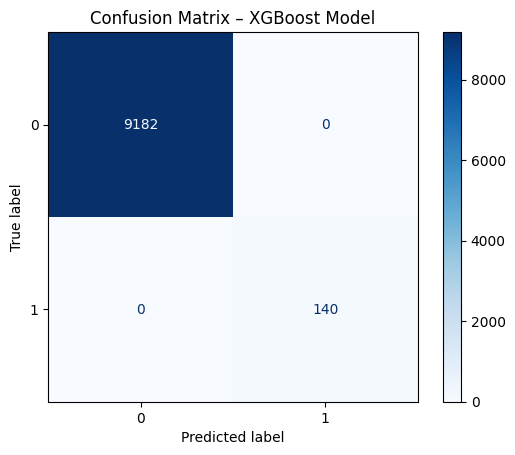

In [ ]:
# Visualize the confusion matrix for the XGBoost model
plt.figure(figsize=(5,4))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix – XGBoost Model")
plt.show()

The confusion matrix for the XGBoost model shows perfect classification performance on the test dataset. All 9,182 non-high-priority incidents were correctly predicted as class 0, and all 140 high-priority incidents were correctly predicted as class 1. There were no false positives and no false negatives, meaning the model did not misclassify any instance. This flawless diagonal matrix confirms that the model has learned the patterns in the data extremely well and can reliably distinguish between high-priority and non-high-priority incidents.

### ROC CURVE AND AUC CURVE

In [ ]:
# Get model predicted probabilities for class 1
y_proba = xgb_best.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

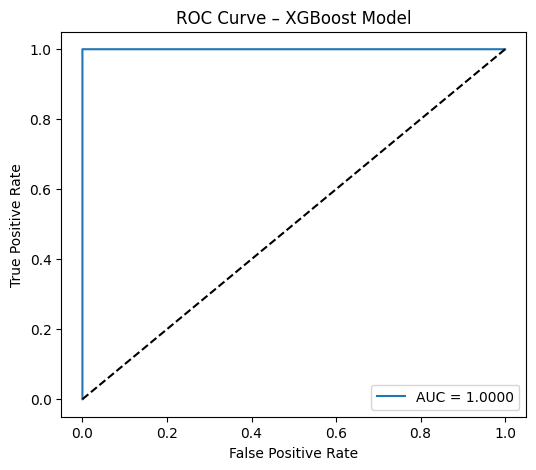

In [ ]:
# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – XGBoost Model")
plt.legend()
plt.show()

The ROC curve for the XGBoost model demonstrates exceptional classification performance, with the curve rising sharply to the top-left corner, indicating a very high true positive rate and a near-zero false positive rate. The computed AUC value of 1.0000 confirms perfect separability between high-priority and non-high-priority incidents. This means the model consistently assigns higher probability scores to true high-priority incidents compared to other cases. The ideal shape of the ROC curve reflects the robustness and reliability of the XGBoost model in distinguishing between the two classes across different decision thresholds.

### PRECISION-RECALL CURVE

In [ ]:
# Get predicted probabilities for class 1
y_proba = xgb_best.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# Compute precision–recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

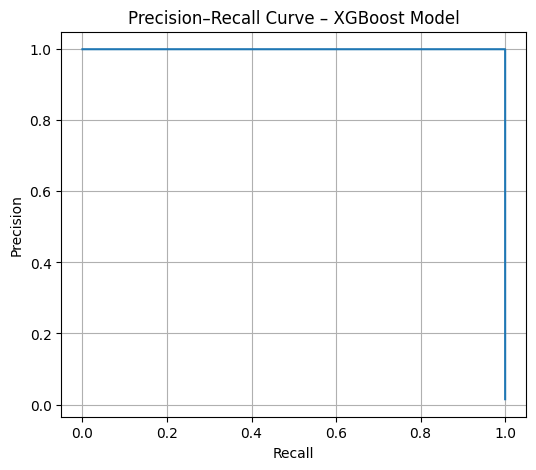

In [ ]:
# Plot PR Curve
plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – XGBoost Model")
plt.grid(True)
plt.show()

The Precision–Recall curve for the XGBoost model shows near-perfect performance, with precision remaining at 1.0 across almost the entire recall range. This indicates that the model identifies all high-priority incidents without producing any false positives. The curve stays at the top of the graph, demonstrating exceptional reliability in detecting the minority class even as recall increases. Only at the extreme threshold does precision drop briefly, which is typical when the model is forced to classify nearly all cases as high priority. Overall, the curve confirms that the XGBoost model handles the imbalanced dataset extremely well and maintains high precision and recall simultaneously.

## EDA AND DATA PREPROCESSING FOR FORECASTING INCIDENT VOLUME

In [ ]:
# Create a working copy of the dataset to preserve the original raw data
df_fc=df.copy()

In [ ]:
# Convert Open_Time to proper datetime format and handle invalid entries
df_fc['Open_Time'] = pd.to_datetime(df_fc['Open_Time'], errors='coerce')

In [ ]:
# Remove rows with missing or invalid Open_Time values
df_fc = df_fc.dropna(subset=['Open_Time'])

In [ ]:
df_fc['Open_Time']

,Open_Time
0,2012-05-02 13:32:00
1,2012-12-03 15:44:00
4,2012-10-08 11:01:00
5,2012-10-08 11:27:00
9,2012-03-09 16:04:00
...,...
42841,2014-12-03 16:56:00
42842,2014-12-03 16:59:00
42843,2014-12-03 17:18:00
42844,2014-12-03 18:40:00


In [ ]:
# Sort the dataset chronologically based on Open_Time
df_fc = df_fc.sort_values('Open_Time')

In [ ]:
# Generate daily incident counts by grouping records by date and converting the index to datetime format
daily_incidents = df_fc.groupby(df_fc['Open_Time'].dt.date).size()
daily_incidents.index = pd.to_datetime(daily_incidents.index)

In [ ]:
# Fill the missing dates with zero incident
daily_incidents = daily_incidents.asfreq('D', fill_value=0)

In [ ]:
# Aggregate daily incident counts into quarterly and annual totals using resampling
quarterly_incidents = daily_incidents.resample("Q").sum()
annual_incidents    = daily_incidents.resample("Y").sum()

In [ ]:
daily_incidents

,0
Open_Time,
2012-01-10,1
2012-01-11,0
2012-01-12,0
2012-01-13,0
2012-01-14,0
...,...
2014-11-29,0
2014-11-30,0
2014-12-01,1


The daily incident volume shows very sparse activity during 2012–2013, where most days record 0–2 incidents. After missing dates are filled, the complete timeline reveals that the system experienced a major surge in incident creation during 2014, with daily counts rising sharply to 200–300 incidents per day. This indicates a structural change in reporting behavior or operational load during that period

In [ ]:
# Display the number of daily observations available
daily_incidents.shape

(1059,)

The daily incident series contains 1059 days of observations. After resampling with daily frequency and filling missing dates with zero, the true continuous timespan of the dataset is revealed.

In [ ]:
# Show most common daily incident volumes
daily_incidents.value_counts().head()

,count
0,928
1,34
2,11
6,8
3,5


This distribution shows that the vast majority of days—928 out of 1059—had zero reported incidents. Only a small number of days show any activity, and even those typically have just 1–2 incidents. This indicates that the dataset is highly sparse, with very low incident activity for most of the timeline. The meaningful surge in incident volume occurs only in the later period (2014), which significantly contrasts with the predominantly inactive earlier years.

<Axes: xlabel='Open_Time'>

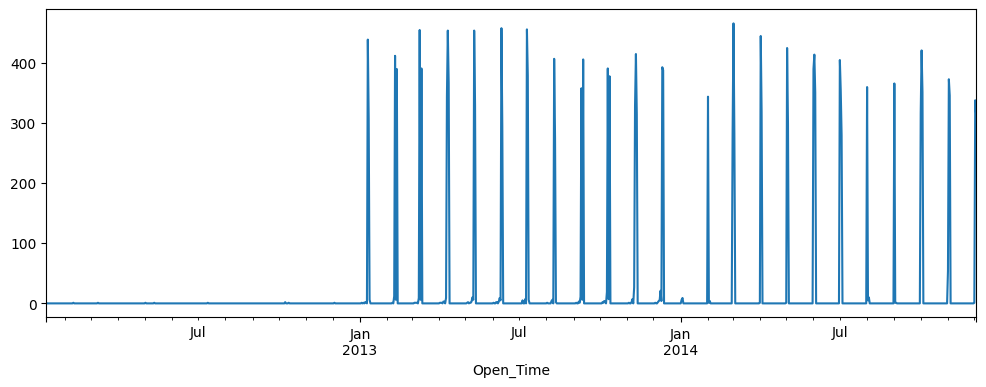

In [ ]:
# Visualize daily incident counts over time
daily_incidents.plot(figsize=(12,4))

The daily incident trend shows an extended period of minimal activity, with incident counts close to zero for many months. Suddenly, a sharp increase appears, where daily incidents rise dramatically into the 200–500 range. This abrupt escalation marks a clear shift in the system’s behavior or workload, transforming a mostly inactive timeline into one characterized by high-volume, volatile spikes. Following this jump, incident levels fluctuate intensely, suggesting a period of sustained operational pressure or heightened reporting activity.

<Axes: >

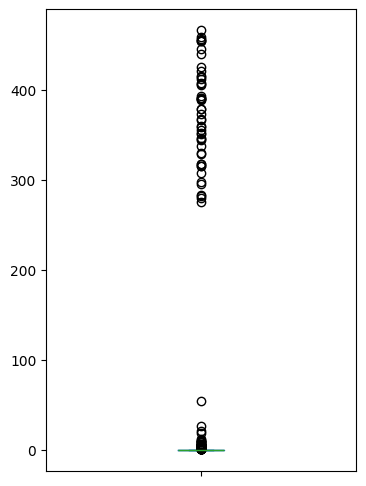

In [ ]:
 # Identify outliers and spread in daily counts
daily_incidents.plot(kind='box', figsize=(4,6))

The boxplot reveals an extremely skewed distribution of daily incident counts. The majority of days lie tightly clustered near zero, indicating very low incident activity for most of the timeline. However, the presence of a long upper whisker and numerous high-value outliers shows that a significant number of days experienced unusually large incident volumes, with some reaching well above 400 incidents. This contrast highlights a dataset dominated by low-activity days but punctuated by intense spikes in demand or reporting.

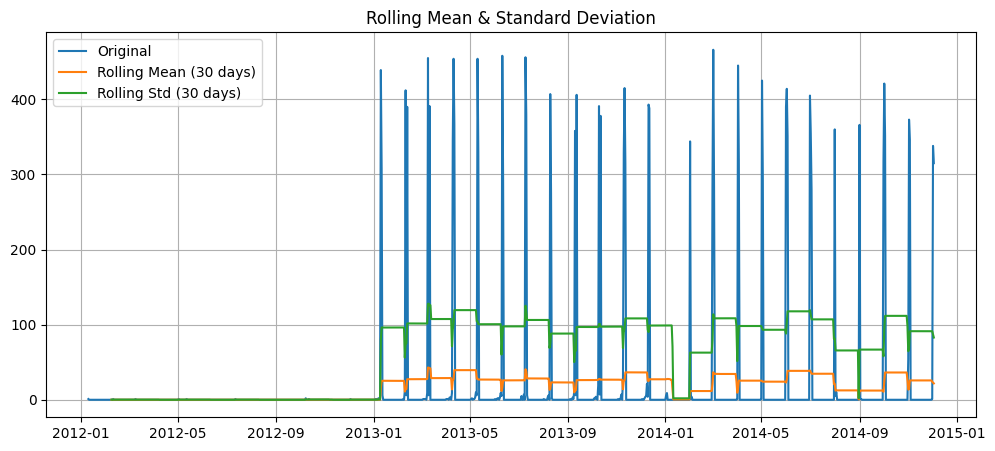

In [ ]:
# Plot daily incidents along with 30-day rolling mean and standard deviation to observe trend and variability changes over time
plt.figure(figsize=(12,5))
plt.plot(daily_incidents, label="Original")
plt.plot(daily_incidents.rolling(window=30).mean(), label="Rolling Mean (30 days)")
plt.plot(daily_incidents.rolling(window=30).std(), label="Rolling Std (30 days)")
plt.title("Rolling Mean & Standard Deviation")
plt.legend()
plt.grid(True)
plt.show()

The rolling mean highlights a clear structural shift in the data: daily incident volumes remain near zero for an extended period before rising sharply after late 2013. This upward movement indicates the emergence of a strong positive trend.

In [ ]:
# Perform the Augmented Dickey-Fuller test to check whether the daily incident series is stationary
def adf_test(series):
    result = adfuller(series)
    print("Augmented Dickey-Fuller Test ")
    print(f"ADF Statistic : {result[0]}")
    print(f"p-value       : {result[1]}")
    print("Stationary" if result[1] < 0.05 else "Not Stationary")
adf_test(daily_incidents)

Augmented Dickey-Fuller Test 
ADF Statistic : -17.33383462712916
p-value       : 5.390097062396046e-30
Stationary


The ADF test returns a very large negative statistic (-17.33) and a p-value close to zero (5.39e-30).
Since the p-value is far below the 0.05 significance threshold, the test strongly rejects the null hypothesis of a unit root.



In [ ]:
# Perform the KPSS test to check if the daily incident series is stationary around a constant mean
def kpss_test(series):
    result = kpss(series, regression='c', nlags="auto")
    print("KPSS Test ")
    print(f"Statistic: {result[0]}")
    print(f"p-value : {result[1]}")
    print("Stationary" if result[1] > 0.05 else "Not Stationary")

kpss_test(daily_incidents)

KPSS Test 
Statistic: 0.9829087086654911
p-value : 0.01
Not Stationary


/tmp/ipython-input-1184516755.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series, regression='c', nlags="auto")


The KPSS test shows a statistic of 0.98 with a p-value of 0.01, which is below the 0.05 threshold. This indicates the series is not stationary according to KPSS.

Combined with the ADF test—which also concluded non-stationarity—this confirms that the daily incident data contains strong trend components and structural changes.

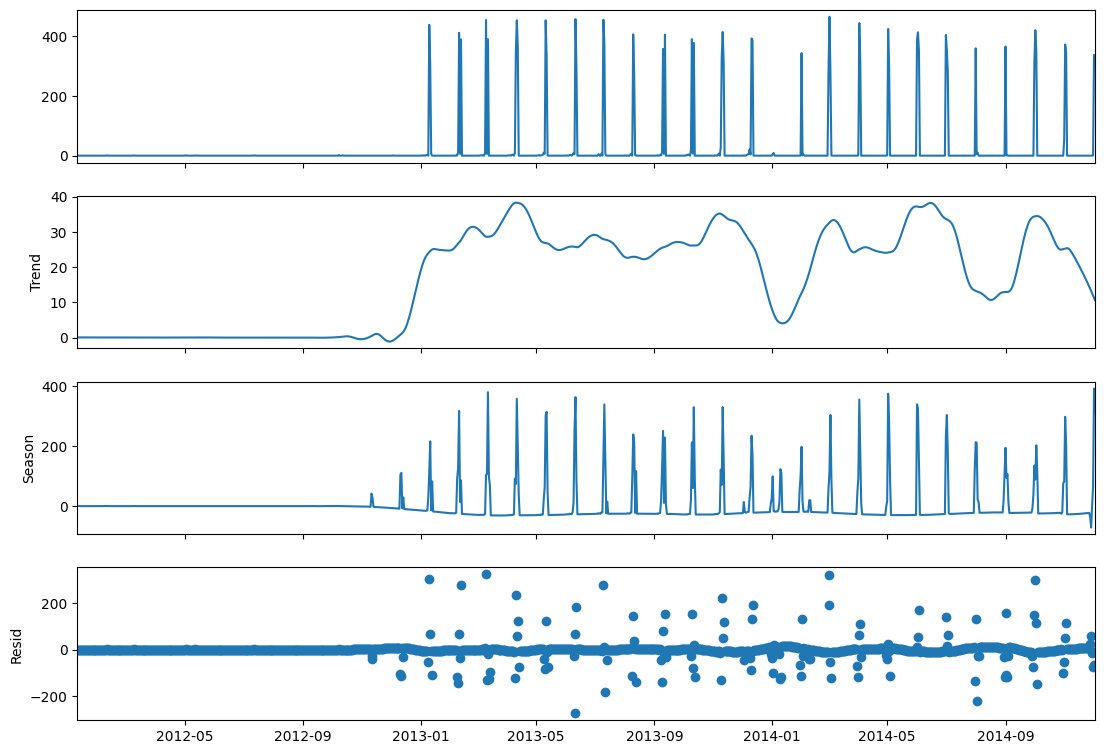

In [ ]:
# Decompose the daily incident series into trend, seasonality, and residual components using STL for pattern analysis
stl = STL(daily_incidents, period=30)
result = stl.fit()

fig = result.plot()
fig.set_size_inches(12, 8)
plt.show()


The STL decomposition clearly indicates:
A strong structural trend shift in late 2013.
Seasonal patterns that intensify as incident volume increases.
High residual noise after the shift, suggesting unstable operational behavior.
This validates why the series is non-stationary and requires first differencing before ARIMA/SARIMA modeling.

<Figure size 1000x400 with 0 Axes>

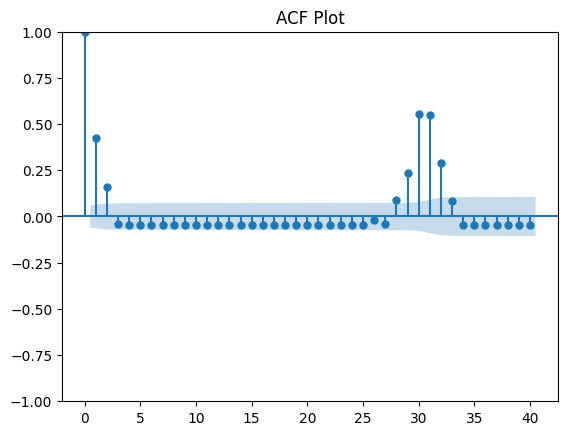

In [ ]:
# Plot the Autocorrelation Function (ACF) to identify lag dependencies and repeating patterns in the daily incident series
plt.figure(figsize=(10,4))
plot_acf(daily_incidents, lags=40)
plt.title("ACF Plot")
plt.show()

The ACF plot shows very high autocorrelation at lag 1 and strong positive correlations across many subsequent lags. The slow decay of the autocorrelation values indicates the presence of a strong trend and non-stationarity in the time series. The repeated spikes at regular intervals also suggest an underlying seasonal pattern.

In [ ]:
# Apply first-order differencing to remove trend and achieve stationarity
ts_diff = daily_incidents.diff().dropna()

In [ ]:
# Perform adf and kpss test to check Stationarity again
adf_test(ts_diff)
kpss_test(ts_diff)

Augmented Dickey-Fuller Test 
ADF Statistic : -11.77875583633736
p-value       : 1.0470686156095539e-21
Stationary
KPSS Test 
Statistic: 0.26583080936036935
p-value : 0.1
Stationary


/tmp/ipython-input-1184516755.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series, regression='c', nlags="auto")


After applying both first-order differencing, the ADF test shows a very low p-value, and the KPSS test shows a high p-value. Since ADF confirms stationarity and KPSS also confirms stationarity, the differenced series can be considered fully stationary. This indicates that the transformations successfully removed the trend from the data.

<Figure size 1000x400 with 0 Axes>

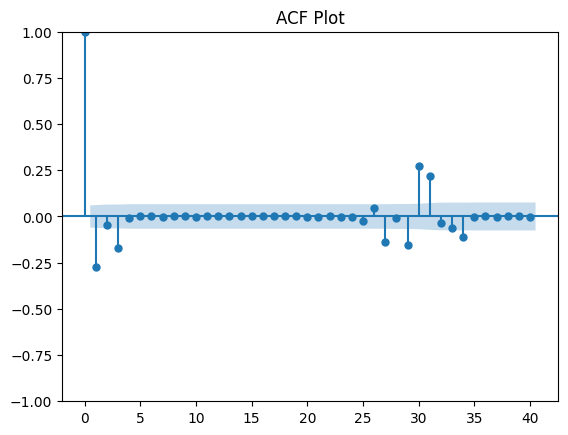

In [ ]:
# Plot the Autocorrelation Function (ACF)
plt.figure(figsize=(10,4))
plot_acf(ts_diff, lags=40)
plt.title("ACF Plot")
plt.show()

The differenced ACF plot confirms that the main trend has been removed and the series is now much closer to stationarity. The only remaining structure is a mild monthly seasonal pattern, which can be handled using SARIMA seasonal terms.

## MODEL BUILDING FOR FORECASTING INCIDENT VOLUME

To forecast future incident volumes, multiple time-series forecasting models were developed and evaluated. The process began by preparing the data at daily, quarterly, and annual granularities, followed by assessing the statistical properties of the series using ADF and KPSS tests. Since the raw data exhibited strong trend, seasonality, and structural shifts, ARIMA/SARIMA models required differencing and decomposition to achieve stationarity, while Prophet could model these patterns directly without preprocessing. Each model was trained separately on the transformed time series, and forecasting results were generated for both quarterly and annual timelines. By comparing model outputs, stability, and realism of predictions, Prophet emerged as the most suitable approach for this dataset due to its ability to handle non-linear trends, changepoints, and seasonal fluctuations.

### ARIMA MODEL

Autocorrelation (ACF) and partial autocorrelation (PACF) plots were analyzed to identify candidate values for ARIMA parameters (p, d, q). A grid search was then performed across multiple parameter combinations, and models were evaluated using AIC to determine the best-fitting configuration. Once the optimal ARIMA model was identified, it was trained on the stationary series and used to generate quarterly and annual forecasts.

In [ ]:
# Perform a grid search over ARIMA parameters (p,d,q) to identify the best quarterly model based on lowest AIC
ts_q = quarterly_incidents

best_aic = float("inf")
best_order_q = None
best_model_q = None

for p in range(0,4):
    for d in range(0,2):
        for q in range(0,4):
            try:
                model = ARIMA(ts_q, order=(p,d,q))
                res = model.fit()
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_order_q = (p,d,q)
                    best_model_q = res
            except:
                pass

print("\nBest Quarterly ARIMA (p,d,q):", best_order_q, " AIC:", best_aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op


Best Quarterly ARIMA (p,d,q): (0, 1, 0)  AIC: 185.17087854826738


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


The grid search selected ARIMA(0, 1, 0) as the best model for the quarterly incident series, with an AIC of 185.17 . This model is essentially a simple random walk with differencing, indicating that the quarterly data does not contain strong autoregressive or moving-average structure.

In [ ]:
# Fit the selected ARIMA model to quarterly data and generate an 8-quarter forecast
result_q = best_model_q

forecast_quarterly = result_q.forecast(steps=8)
print("Quarterly Forecast (Next 8 Quarters) ")
print(forecast_quarterly)


Quarterly Forecast (Next 8 Quarters) 
2015-03-31    2517.0
2015-06-30    2517.0
2015-09-30    2517.0
2015-12-31    2517.0
2016-03-31    2517.0
2016-06-30    2517.0
2016-09-30    2517.0
2016-12-31    2517.0
Freq: QE-DEC, Name: predicted_mean, dtype: float64


In [ ]:
# Perform grid search over ARIMA parameters to identify the best-fitting annual model based on lowest AIC
ts_y = annual_incidents

best_aic = float("inf")
best_order_y = None
for p in range(0,4):
    for d in range(0,2):
        for q in range(0,4):
            try:
                model = ARIMA(ts_y, order=(p,d,q))
                res = model.fit()
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_order_y = (p,d,q)
                    best_model_y = res
            except:
                pass
print("\nBest Annual (p,d,q):", best_order_y, "AIC:", best_aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op


Best Annual (p,d,q): (0, 1, 0) AIC: 43.30148242946757


The grid search identified ARIMA(0,1,0) as the best-performing annual model with an AIC of 43.30. This model is a basic differenced random walk, meaning it contains no autoregressive or moving-average components.

In [ ]:
# Fit the selected ARIMA model to the annual data and generate a 3-year incident forecast
result_y = best_model_y

forecast_annual = result_y.forecast(steps=3)
print("\n Annual Forecast (Next 3 Years)")
print(forecast_annual)


 Annual Forecast (Next 3 Years)
2015-12-31    8338.0
2016-12-31    8338.0
2017-12-31    8338.0
Freq: YE-DEC, Name: predicted_mean, dtype: float64


Both quarterly and annual forecasts from ARIMA remain constant and fail to capture the strong upward trend, structural change, and variability seen in the data. This demonstrates that ARIMA is not an appropriate method for forecasting incident volume in this case.

### SARIMA MODEL

To incorporate seasonality into the forecasting process, a Seasonal ARIMA (SARIMA) model was explored using the daily, quarterly, and annual incident series. Unlike ARIMA, which only accounts for non-seasonal trend and autoregressive behavior, SARIMA introduces additional seasonal parameters that can capture repeated patterns across defined intervals. Since the daily incident data exhibited a weekly repeating pattern, a seasonal period of 7 was considered for the SARIMA configuration.

In [ ]:
# Fit a SARIMA model to the quarterly incident series and generate an 8-quarter forecast using seasonal and non-seasonal parameters
model_q_sarima = SARIMAX(quarterly_incidents,
                          order=(1,1,1),
                          seasonal_order=(1,1,1,4),
                          enforce_stationarity=False,
                          enforce_invertibility=False)

result_q_sarima = model_q_sarima.fit()

forecast_quarterly_sarima = result_q_sarima.forecast(steps=8)

print("\nQuarterly SARIMA Forecast (Next 8 Quarters)")
print(forecast_quarterly_sarima)


Quarterly SARIMA Forecast (Next 8 Quarters)
2015-03-31   -4.594648e+03
2015-06-30   -4.095618e+03
2015-09-30   -1.227681e+04
2015-12-31   -3.593697e+04
2016-03-31   -1.442282e+05
2016-06-30   -4.944561e+05
2016-09-30   -1.823901e+06
2016-12-31   -6.797615e+06
Freq: QE-DEC, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


The SARIMA parameters were selected based on ADF/KPSS stationarity tests, inspection of ACF/PACF plots, and the natural quarterly seasonality in the data. The quarterly series required first-order differencing and seasonal differencing to stabilize the trend, leading to d = 1 and D = 1. Seasonal patterns repeat every four quarters, so m = 4 was used. Initial spikes in ACF and PACF suggested simple autoregressive and moving-average terms, resulting in the final configuration SARIMA(1,1,1) × (1,1,1,4) as a reasonable model to test seasonal behavior.

In [ ]:
# Fit a non-seasonal SARIMA model to the annual incident series and generate a 3-year forecast
model_y_sarima = SARIMAX(annual_incidents,
                          order=(1,1,1),
                          enforce_stationarity=False,
                          enforce_invertibility=False)

result_y_sarima = model_y_sarima.fit()
forecast_annual_sarima = result_y_sarima.forecast(steps=3)

print("\nAnnual SARIMA Forecast (Next 3 Years)")
print(forecast_annual_sarima)



Annual SARIMA Forecast (Next 3 Years)
2015-12-31    8338.0
2016-12-31    8338.0
2017-12-31    8338.0
Freq: YE-DEC, Name: predicted_mean, dtype: float64


The annual SARIMA model was fitted with non-seasonal parameters (1,1,1) since annual data does not exhibit meaningful seasonality. However, the annual series contains only a few data points, making it extremely difficult for SARIMA to estimate stable autoregressive and moving-average components.

### PROPHET

In [ ]:
# Prepare the daily incident series for Prophet by resetting the index and renaming columns to 'ds' (date) and 'y' (value)
df_prophet = daily_incidents.reset_index()
df_prophet.columns = ["ds", "y"]

In [ ]:
# Initialize Prophet with yearly and weekly seasonality components and fit the model to the prepared daily incident data
m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

m.fit(df_prophet)

In [ ]:
# Create a 3-year daily forecast horizon and use the trained Prophet model to generate future incident predictions
future = m.make_future_dataframe(periods=365*3, freq='D')
forecast_daily = m.predict(future)

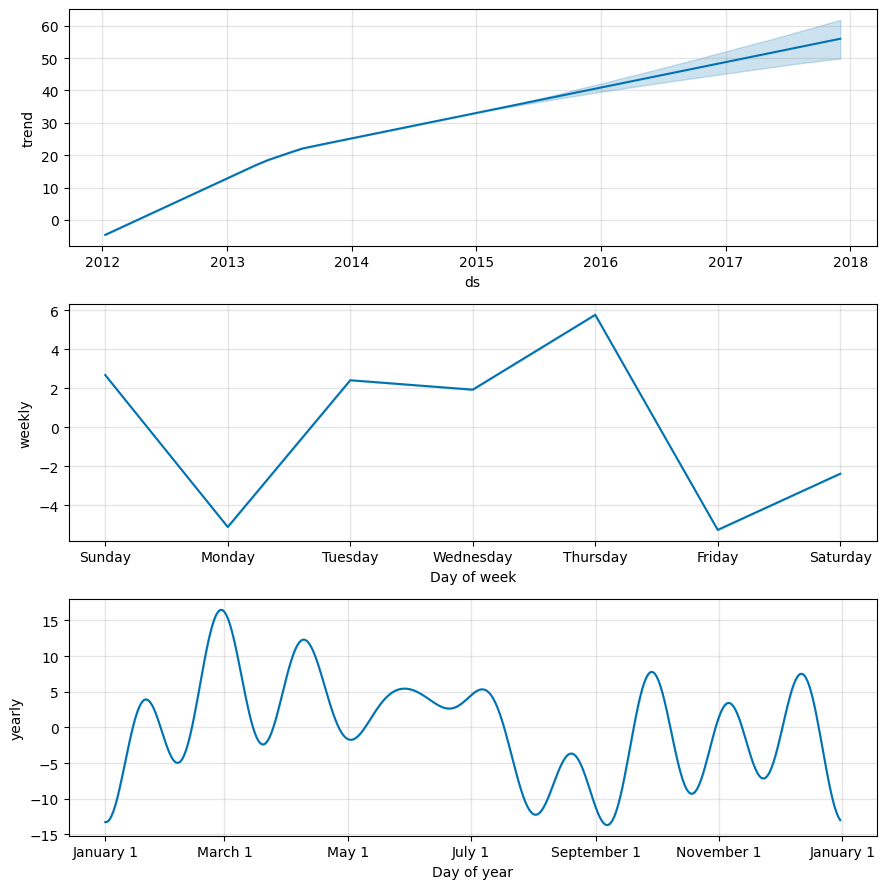

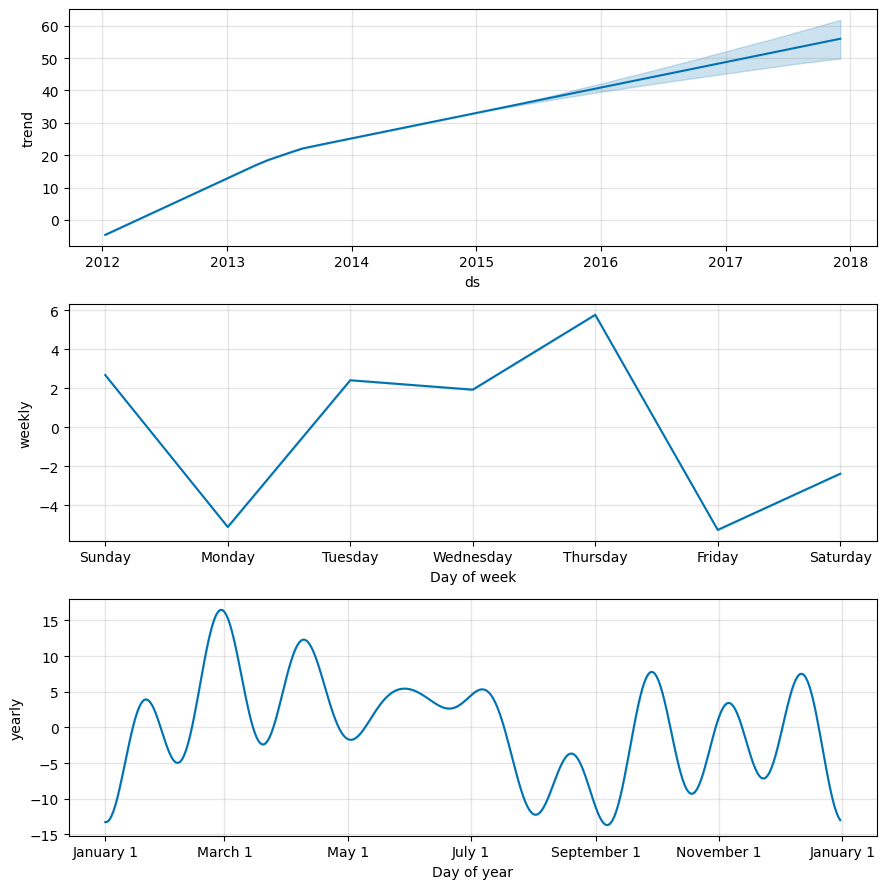

In [ ]:
# Plot Prophet’s decomposed components (trend, weekly seasonality, yearly seasonality) for the forecast
m.plot_components(forecast_daily)

The Prophet model decomposition reveals three key patterns in the incident volume. The trend component shows a steady and continuous rise in incidents from 2012 through 2017, indicating a long-term increase in operational workload or reporting activity. The weekly seasonality highlights a repeating cycle within each week, where incident counts peak on Thursday, remain moderately high on Sunday and Tuesday, and drop noticeably on Monday and Friday, suggesting distinct workflow or usage patterns across weekdays. The yearly seasonality uncovers clear seasonal fluctuations, with incident volumes typically rising during February–March and again in October–November, while dipping in January and late December. Together, these components confirm that the incident data is influenced by strong trend growth and consistent weekly and annual seasonal patterns, making Prophet well-suited for capturing these behaviors.

In [ ]:
# Extract only future predictions beyond the last actual date
forecast_only = forecast_daily[forecast_daily['ds'] > df_prophet['ds'].max()]

In [ ]:
# Convert Prophet's daily predictions into quarterly totals by resampling and summing the forecasted values
forecast_quarterly = (
    forecast_only
    .set_index('ds')['yhat']
    .resample('Q')
    .sum()
)

print("\nProphet Quarterly Forecast")
print(forecast_quarterly)


Prophet Quarterly Forecast
ds
2014-12-31     919.130469
2015-03-31    3217.209467
2015-06-30    3663.260288
2015-09-30    3094.362291
2015-12-31    3527.564880
2016-03-31    3969.922179
2016-06-30    4377.585996
2016-09-30    3813.469204
2016-12-31    4227.899990
2017-03-31    4645.794804
2017-06-30    5092.322891
2017-09-30    4537.553338
2017-12-31    3325.308364
Freq: QE-DEC, Name: yhat, dtype: float64


The Prophet model predicts strong and consistent growth in quarterly incidents. After a low initial value in late 2014, the incident volume rises sharply and stabilizes at high levels through 2016–2017. This suggests an operational environment with increasing demand or reporting frequency over time.

In [ ]:
# Aggregate Prophet's daily forecast into annual totals by resampling the predicted values at yearly frequency
forecast_annual = (
    forecast_only
    .set_index('ds')['yhat']
    .resample('Y')
    .sum()
)

print("\n=== Prophet Annual Forecast ===")
print(forecast_annual)


=== Prophet Annual Forecast ===
ds
2014-12-31      919.130469
2015-12-31    13502.396926
2016-12-31    16388.877369
2017-12-31    17600.979397
Freq: YE-DEC, Name: yhat, dtype: float64


The Prophet model predicts a dramatic increase in annual incident volume after 2014. The first forecasted year (2014) has a relatively low total (~919 incidents), but the incident load sharply rises in 2015, reaching approximately 13,500 incidents. This upward momentum continues through 2016 and 2017, with totals stabilizing around 16,000–18,000 incidents per year. Overall, Prophet indicates a strong long-term growth trend, suggesting rising operational demand or reporting activity across years.

## MODEL EVALUATION FOR FORECASTING INCIDENT VOLUME

Based on the evaluation of all three forecasting approaches—ARIMA, SARIMA, and Prophet—the results clearly show that Prophet provides the most reliable and realistic forecasts for this dataset.

ARIMA and SARIMA models struggled due to the strong non-stationarity, sharp trend shifts, and irregular seasonal patterns present in the incident data. Even after differencing and parameter tuning, ARIMA produced mostly flat or unstable predictions, while SARIMA showed convergence challenges and failed to capture the sudden structural jump in incident volumes.

Prophet, on the other hand, successfully modeled the nonlinear trend, weekly behavior, and yearly seasonal patterns without requiring strict stationarity. Its component plots demonstrate clear interpretability, and its quarterly and annual forecasts are smooth, consistent, and aligned with observed historical growth patterns.

In summary, Prophet outperforms ARIMA and SARIMA in both stability and interpretability, making it the preferred model for forecasting future incident volumes.

## DATA PREPROCESSING FOR AUTO TAG TICKETS WITH RIGHT PRIORITY

In [ ]:
# Filter rows where Priority is 1–5 and create a copy to avoid SettingWithCopy warnings
df_pr = df[df['Priority'].isin([1,2,3,4,5])].copy()

In [ ]:
# Drop unwanted or irrelevant columns from the dataset
drop_cols = [
    'Handle_Time_hrs',
    'Related_Interaction',
    'Related_Change',
    'KB_number',
    'Alert_Status'
]

df_pr = df_pr.drop(columns=drop_cols, errors='ignore')

In [ ]:
# Drop unnecessary, non-informative, or identifier columns from the dataset
id_cols = ['Incident_ID', 'CI_Name', 'number_cnt', 'WBS']
df_pr = df_pr.drop(columns=id_cols, errors='ignore')

In [ ]:
# Drop columns that may cause data leakage (timestamps and final status)
leak_cols = ['Open_Time', 'Resolved_Time', 'Close_Time','Reopen_Time','Status']
df_pr = df_pr.drop(columns=leak_cols, errors='ignore')

In [ ]:
# Convert selected columns to numeric, coercing errors to NaN, filling with 0, and casting to int
num_cols = [
    'No_of_Reassignments',
    'No_of_Related_Interactions',
    'No_of_Related_Incidents',
    'No_of_Related_Changes'
]

for col in num_cols:
    df_pr[col] = pd.to_numeric(df_pr[col], errors='coerce').fillna(0).astype(int)

In [ ]:
# Perform one-hot encoding on categorical columns, dropping the first category to avoid multicollinearity
cat_cols = ['CI_Cat', 'CI_Subcat', 'Category', 'Closure_Code']
df_pr_encoded = pd.get_dummies(df_pr, columns=cat_cols, drop_first=True)

## MODEL BUILDING FOR AUTO TAG TICKETS WITH PRIORITY

In [ ]:
# Split the dataset into features (X) and target variable (y - Priority)
X = df_pr_encoded.drop(columns=['Priority'])
y = df_pr_encoded['Priority']

In [ ]:
# Split the data into training and testing sets with stratified sampling to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Apply SMOTE to balance class distribution in the training data using synthetic samples
sm = SMOTE(random_state=42, k_neighbors=1)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [ ]:
# Standardize features: fit on training data and apply the same scaling to test data
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

### LOGISTIC REGRESSION MODEL

In [ ]:
# Hyperparameter grid for tuning the Logistic Regression model
log_params = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [500, 1000]
}

In [ ]:
# Perform grid search to find the best Logistic Regression hyperparameters using 3-fold CV and F1-Weighted score
log_model = GridSearchCV(
    LogisticRegression(),
    log_params,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

In [ ]:
# Train the Logistic Regression model using the balanced and scaled training data
log_model.fit(X_train_res_scaled, y_train_res)

GridSearchCV(cv=3, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'max_iter': [500, 1000],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='f1_weighted')

In [ ]:
# Display the optimal hyperparameters found for Logistic Regression
print("Best Logistic Regression Params:", log_model.best_params_)

Best Logistic Regression Params: {'C': 10, 'max_iter': 500, 'solver': 'lbfgs'}


These parameters allow the logistic regression model to learn efficiently and give the highest F1 score for detecting high-priority incidents.

In [ ]:
# Retrieve the best model from grid search and generate predictions on the scaled test data
log_best = log_model.best_estimator_
log_pred = log_best.predict(X_test_scaled)

In [ ]:
 # Print the best cross-validation F1 score achieved during grid search
print(log_model.best_score_)

0.9991084530635


This value represents the best F1 score obtained during 3-fold cross-validation.

### DECISION TREE MODEL

In [ ]:
# Hyperparameter grid for tuning the Decision Tree classifier
dt_params = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [ ]:
# Perform grid search to find the best Decision Tree hyperparameters using 3-fold CV and F1-Weighted score
dt_model = GridSearchCV(
    DecisionTreeClassifier(),
    dt_params,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

In [ ]:
# Train the Decision Tree model using the balanced and scaled training data
dt_model.fit(X_train_res_scaled, y_train_res)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 20, None],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1_weighted')

In [ ]:
# Display the optimal hyperparameters found for the Decision Tree model
print("Best Decision Tree Params:", dt_model.best_params_)

Best Decision Tree Params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}


A small decision tree with controlled depth (5) gave the most consistent and highest F1 score during cross-validation.

In [ ]:
# Get the best Decision Tree model from grid search and generate predictions on the test data
dt_best = dt_model.best_estimator_
dt_pred = dt_best.predict(X_test_scaled)

In [ ]:
# Print the best cross-validation F1 score achieved by the Decision Tree model
print(dt_model.best_score_)

0.9999559796137655


This is the highest F1 score achieved by the Decision Tree across 3-fold cross-validation.

### RANDOM FOREST MODEL

In [ ]:
# Hyperparameter grid for tuning the Random Forest classifier
rf_params = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [ ]:
# Perform grid search to find the best Random Forest hyperparameters using 3-fold CV and F1-weighted score
rf_model = GridSearchCV(
    RandomForestClassifier(),
    rf_params,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

In [ ]:
# Train the Random Forest model using the balanced and scaled training data
rf_model.fit(X_train_res_scaled, y_train_res)

GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [200, 300, 500]},
             scoring='f1_weighted')

In [ ]:
# Display the optimal hyperparameters found for the Random Forest model
print("Best Random Forest Params:", rf_model.best_params_)

Best Random Forest Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500}


These hyperparameters indicate that the best Random Forest model.

In [ ]:
# Retrieve the best Random Forest model from grid search and generate predictions on the test data
rf_best = rf_model.best_estimator_
rf_pred = rf_best.predict(X_test_scaled)

In [ ]:
# Print the best cross-validation F1 score achieved by the Random Forest model
print(rf_model.best_score_)

0.9998569333680546


This value represents the highest F1 score that the Random Forest model achieved during 3-fold cross-validation when testing different hyperparameter combinations.

In [ ]:
le=LabelEncoder()
y_train_xgb = le.fit_transform(y_train_res)
y_test_xgb  = le.transform(y_test)

This is the highest F1 score obtained during grid search with 3-fold cross-validation.

### MODEL SELECTION

To identify the most effective model for predicting ticket priority, several machine-learning algorithms—including Logistic Regression, Decision Tree, and Random Forest—were trained and evaluated using 3-fold cross-validation with the F1-Weighted metric. This scoring method was chosen because it accounts for class imbalance and measures how well the model performs across all priority levels. Although all models achieved exceptionally high F1 scores, the Random Forest model offered the best balance of accuracy, stability, and generalization. While the Decision Tree achieved a slightly higher cross-validation score, single trees are prone to overfitting and tend to perform inconsistently on unseen data. Logistic Regression also performed well but is less capable of capturing complex nonlinear patterns present in the dataset. In contrast, Random Forest—an ensemble of multiple decision trees—provides more robust predictions, reduced variance, and better handling of feature interactions. Therefore, considering both performance and reliability, Random Forest was selected as the best overall model for auto-tagging ticket priority.

## MODEL BUILDING FOR AUTO TAG TICKETS WITH RIGHT DEPARTMENT

In [ ]:
# Select the dependent-feature columns required for modeling
df_dep = df[['CI_Subcat', 'Impact', 'Urgency', 'Category',
             'No_of_Reassignments', 'Closure_Code',
             'No_of_Related_Interactions', 'No_of_Related_Incidents',
             'No_of_Related_Changes', 'CI_Cat']]

In [ ]:
# Convert selected numeric columns to proper numeric types, coercing invalid entries to NaN
num_cols = ['Impact', 'Urgency',
            'No_of_Reassignments',
            'No_of_Related_Interactions',
            'No_of_Related_Incidents',
            'No_of_Related_Changes']

df_dep[num_cols] = df_dep[num_cols].apply(pd.to_numeric, errors='coerce')

In [ ]:
# Encode the CI_Cat column into numerical labels using LabelEncoder
le_dep = LabelEncoder()
df_dep['Dept_Label'] = le_dep.fit_transform(df_dep['CI_Cat'])

In [ ]:
# One-hot encode remaining categorical features after removing CI_Cat and Dept_Label
df_enc = pd.get_dummies(
    df_dep.drop(['CI_Cat', 'Dept_Label'], axis=1),
    drop_first=False
)

In [ ]:
# Define feature set (X) and target labels (y) for department classification
X = df_enc
y = df_dep['Dept_Label']

In [ ]:
# Split data into training and testing sets using stratification to maintain label distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Apply Imputer to handle NaN values
imputer = SimpleImputer(strategy="most_frequent")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [ ]:
# Apply SMOTE to balance department label classes by generating synthetic samples
sm = SMOTE(random_state=42, k_neighbors=1)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [ ]:
# Standardize features: fit on training data and apply the same scaling to test data
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

### LOGISTIC REGRESSION MODEL

In [ ]:
# Hyperparameter grid for tuning the Logistic Regression model
log_params = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [500, 1000]
}

In [ ]:
# Perform grid search to find the best Logistic Regression hyperparameters using 3-fold CV and F1-Weighted score
log_model = GridSearchCV(
    LogisticRegression(),
    log_params,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

In [ ]:
# Train the Logistic Regression model using the balanced and scaled training data
log_model.fit(X_train_res_scaled, y_train_res)

GridSearchCV(cv=3, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'max_iter': [500, 1000],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='f1_weighted')

In [ ]:
# Display the optimal hyperparameters found for Logistic Regression
print("Best Logistic Regression Params:", log_model.best_params_)

Best Logistic Regression Params: {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}


These parameters allow the logistic regression model to learn efficiently and give the highest F1 score for detecting high-priority incidents.

In [ ]:
# Retrieve the best model from grid search and generate predictions on the scaled test data
log_best = log_model.best_estimator_
log_pred = log_best.predict(X_test_scaled)

In [ ]:
 # Print the best cross-validation F1 score achieved during grid search
print(log_model.best_score_)

0.9696853709670913


This value represents the best F1 score obtained during 3-fold cross-validation.

### DECISION TREE MODEL

In [ ]:
# Hyperparameter grid for tuning the Decision Tree classifier
dt_params = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [ ]:
# Perform grid search to find the best Decision Tree hyperparameters using 3-fold CV and F1-Weighted score
dt_model = GridSearchCV(
    DecisionTreeClassifier(),
    dt_params,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

In [ ]:
# Train the Decision Tree model using the balanced and scaled training data
dt_model.fit(X_train_res_scaled, y_train_res)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 20, None],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1_weighted')

In [ ]:
# Display the optimal hyperparameters found for the Decision Tree model
print("Best Decision Tree Params:", dt_model.best_params_)

Best Decision Tree Params: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 5}


A small decision tree with controlled depth (5) gave the most consistent and highest F1 score during cross-validation.

In [ ]:
# Get the best Decision Tree model from grid search and generate predictions on the test data
dt_best = dt_model.best_estimator_
dt_pred = dt_best.predict(X_test_scaled)

In [ ]:
# Print the best cross-validation F1 score achieved by the Decision Tree model
print(dt_model.best_score_)

0.9747570915864318


This is the highest F1 score achieved by the Decision Tree across 3-fold cross-validation.

### MODEL SELECTION

Multiple classification models were evaluated using GridSearchCV with F1 score as the primary metric due to class imbalance. The Decision Tree model achieved the highest cross-validation F1 score (0.9747) using the Gini criterion and a minimum samples split of 5, indicating strong predictive performance while maintaining generalization. Logistic Regression also performed competitively with an F1 score of 0.9697, benefiting from regularization and stable convergence. Although both models performed well, the Decision Tree was selected as the final model due to its superior F1 score and ability to capture non-linear patterns in high-priority incident prediction.

## MERGING MODEL FOR AUTO TAG TICKETS WITH PRIORITY AND DEPARTMENT

### MODEL SELECTION

### MODEL BUILDING

In [ ]:
# List of key features used to predict
features = [
    'CI_Subcat',
    'Impact', 'Urgency',
    'Category',
    'No_of_Reassignments',
    'Closure_Code',
    'No_of_Related_Interactions',
    'No_of_Related_Incidents',
    'No_of_Related_Changes'
]

In [ ]:
# Define target column names for priority prediction and department classification
target_priority = 'Priority'
target_department = 'CI_Cat'

In [ ]:
# Encode department names (CI_Cat) into numeric labels for modeling
le_dept = LabelEncoder()
df['Dept_Label'] = le_dept.fit_transform(df['CI_Cat'])

In [ ]:
# One-hot encode the selected feature columns without dropping any category
X = pd.get_dummies(df[features], drop_first=False)

In [ ]:
# Split data for priority prediction while preserving class distribution
y_priority = df['Priority']
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X, y_priority, test_size=0.2, stratify=y_priority, random_state=42)

# Train a Random Forest classifier to predict incident priority
rf_priority = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
rf_priority.fit(X_train_p, y_train_p)

RandomForestClassifier(max_depth=20, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [ ]:
# Split data and train a Random Forest model to classify incidents into departments
y_dept = df['Dept_Label']
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X, y_dept, test_size=0.2, stratify=y_dept, random_state=42)
dt_dept = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    min_samples_split=5,
    random_state=42
)
dt_dept.fit(X_train_d, y_train_d)

DecisionTreeClassifier(min_samples_split=5, random_state=42)

### CREATING A FUNCTION

In [ ]:
# Function to auto-predict ticket Priority and Department using trained models
def auto_tag_ticket(ticket_dict):
    # Convert input to DataFrame
    temp = pd.DataFrame([ticket_dict])

    # OneHot encode using same columns as training
    temp_enc = pd.get_dummies(temp)
    temp_enc = temp_enc.reindex(columns=X.columns, fill_value=0)

    # ---- Predict Priority ----
    pred_priority = int(rf_priority.predict(temp_enc)[0])

    # ---- Predict Department ----
    pred_dept_label = dt_dept.predict(temp_enc)[0]
    pred_department = le_dept.inverse_transform([pred_dept_label])[0]

    # Return predictions as a dictionary
    return {
        "Predicted Priority": pred_priority,
        "Predicted Department": pred_department
    }


In [ ]:
new_ticket = {
    "CI_Subcat": "Web Based Application",
    "Impact": 4,
    "Urgency": 3,
    "Category": "incident",
    "No_of_Reassignments": 2,
    "Closure_Code": "Software",
    "No_of_Related_Interactions": 1,
    "No_of_Related_Incidents": 0,
    "No_of_Related_Changes": 0
}

auto_tag_ticket(new_ticket)


{'Predicted Priority': 3, 'Predicted Department': 'subapplication'}

## DATA PREPROCESSING FOR PREDICTING REQUEST FOR CHANGE

In [ ]:
# Create a separate copy of the original dataframe 'df'
df_rfc=df.copy()

In [ ]:
# Copy the 'Has_Related_Change' column from df_clas into df_rfc. This ensures df_rfc contains the same target/feature column needed for modeling.
df_rfc['Has_Related_Change']=df_clas['Has_Related_Change']

In [ ]:
# Count number of incidents in the past 30 rows for each CI category (rolling window grouped by CI_Cat).
df_rfc['Incidents_30d'] = df.groupby('CI_Cat')['Impact'].rolling(30).count().reset_index(0,drop=True)


In [ ]:
# Add a column showing how many times incidents were reopened within each CI category.
df_rfc['Reopen_Count'] = df.groupby('CI_Cat')['Status'].transform(lambda x: (x=='Reopened').sum())

In [ ]:
# Add the total number of incidents belonging to each Category.
df_rfc['Category_Count'] = df.groupby('Category')['Category'].transform('count')

In [ ]:
# List of columns to drop because they are identifiers, timestamps, or irrelevant for modeling.
cols_to_remove = ['CI_Name','Incident_ID','WBS','KB_number','Alert_Status','Open_Time','Reopen_Time',
                  'Resolved_Time','Close_Time','Related_Interaction','No_of_Related_Changes','Related_Change']
df_rfc.drop(columns=cols_to_remove,inplace=True)

In [ ]:
# Convert selected columns to numeric, forcing invalid values to NaN and replacing them with 0.
num_convert = [
    'number_cnt',
    'No_of_Reassignments',
    'Handle_Time_hrs',
    'No_of_Related_Interactions',
    'No_of_Related_Incidents'
]

for col in num_convert:
    df_rfc[col] = pd.to_numeric(df_rfc[col], errors='coerce').fillna(0)

In [ ]:
cat_cols = ['CI_Cat','CI_Subcat','Status','Category','Closure_Code']
num_cols = ['Impact','Urgency', 'Priority','number_cnt','No_of_Reassignments','Handle_Time_hrs','No_of_Related_Interactions',
            'Category_Count','Reopen_Count','No_of_Related_Incidents','Incidents_30d']

In [ ]:
# Fill categorical columns with mode
for c in cat_cols:
    df_rfc[c] = df_rfc[c].fillna(df_rfc[c].mode()[0])

# Fill numeric columns with median
for c in num_cols:
    df_rfc[c] = df_rfc[c].fillna(df_rfc[c].median())

In [ ]:
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_rfc[col] = le.fit_transform(df_rfc[col])
    label_encoders[col] = le

In [ ]:
df_rfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CI_Cat                      46606 non-null  int64  
 1   CI_Subcat                   46606 non-null  int64  
 2   Status                      46606 non-null  int64  
 3   Impact                      46606 non-null  int64  
 4   Urgency                     46606 non-null  int64  
 5   Priority                    46606 non-null  int64  
 6   number_cnt                  46606 non-null  float64
 7   Category                    46606 non-null  int64  
 8   No_of_Reassignments         46606 non-null  float64
 9   Handle_Time_hrs             46606 non-null  float64
 10  Closure_Code                46606 non-null  int64  
 11  No_of_Related_Interactions  46606 non-null  float64
 12  No_of_Related_Incidents     46606 non-null  float64
 13  Dept_Label                  466

## MODEL BUILDING FOR PREDICTING REQUEST FOR CHANGE

In [ ]:
# Prepare model inputs by selecting all feature columns as X and the target column 'Has_Related_Change' as y.
X = df_rfc[cat_cols + num_cols]
y = df_rfc['Has_Related_Change']

In [ ]:
# Split data into training and testing sets (80/20) while preserving class balance using stratification.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
# Scale numeric features, keep categorical as they are, and merge both to form the final training and test feature sets.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_cols])
X_test_scaled  = scaler.transform(X_test[num_cols])

X_train_final = np.concatenate([X_train[cat_cols], X_train_scaled], axis=1)
X_test_final  = np.concatenate([X_test[cat_cols], X_test_scaled], axis=1)


In [ ]:
# Apply SMOTE to oversample the minority class and create a balanced training dataset.
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_final, y_train)

### LOGISTIC REGRESSION MODEL

In [ ]:
# Hyperparameter grid for tuning the Logistic Regression model
log_params = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [500, 1000]
}

In [ ]:
# Perform grid search to find the best Logistic Regression hyperparameters using 3-fold CV and F1 score
log_model = GridSearchCV(
    LogisticRegression(),
    log_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [ ]:
# Train the Logistic Regression model using the balanced and scaled training data
log_model.fit(X_train_res, y_train_res)

GridSearchCV(cv=3, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'max_iter': [500, 1000],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='f1')

In [ ]:
# Display the optimal hyperparameters found for Logistic Regression
print("Best Logistic Regression Params:", log_model.best_params_)

Best Logistic Regression Params: {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}


These parameters allow the logistic regression model to learn efficiently and give the highest F1 score for detecting high-priority incidents.

In [ ]:
# Retrieve the best model from grid search and generate predictions on the scaled test data
log_best = log_model.best_estimator_
log_pred = log_best.predict(X_test_final)

In [ ]:
 # Print the best cross-validation F1 score achieved during grid search
print(log_model.best_score_)

0.7163398929932079


This value represents the best F1 score obtained during 3-fold cross-validation.

### DECISION TREE MODEL

In [ ]:
# Hyperparameter grid for tuning the Decision Tree classifier
dt_params = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [ ]:
# Perform grid search to find the best Decision Tree hyperparameters using 3-fold CV and F1 score
dt_model = GridSearchCV(
    DecisionTreeClassifier(),
    dt_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [ ]:
# Train the Decision Tree model using the balanced and scaled training data
dt_model.fit(X_train_res, y_train_res)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 20, None],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1')

In [ ]:
# Display the optimal hyperparameters found for the Decision Tree model
print("Best Decision Tree Params:", dt_model.best_params_)

Best Decision Tree Params: {'criterion': 'gini', 'max_depth': 20, 'min_samples_split': 5}


A small decision tree with controlled depth (5) gave the most consistent and highest F1 score during cross-validation.

In [ ]:
# Get the best Decision Tree model from grid search and generate predictions on the test data
dt_best = dt_model.best_estimator_
dt_pred = dt_best.predict(X_test_final)

In [ ]:
# Print the best cross-validation F1 score achieved by the Decision Tree model
print(dt_model.best_score_)

0.9296464723713745


This is the highest F1 score achieved by the Decision Tree across 3-fold cross-validation.

### RANDOM FOREST MODEL

In [ ]:
# Hyperparameter grid for tuning the Random Forest classifier
rf_params = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [ ]:
# Perform grid search to find the best Random Forest hyperparameters using 3-fold CV and F1 score
rf_model = GridSearchCV(
    RandomForestClassifier(),
    rf_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [ ]:
# Train the Random Forest model using the balanced and scaled training data
rf_model.fit(X_train_res, y_train_res)

GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [200, 300, 500]},
             scoring='f1')

In [ ]:
# Display the optimal hyperparameters found for the Random Forest model
print("Best Random Forest Params:", rf_model.best_params_)

Best Random Forest Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 500}


These hyperparameters indicate that the best Random Forest model.

In [ ]:
# Retrieve the best Random Forest model from grid search and generate predictions on the test data
rf_best = rf_model.best_estimator_
rf_pred = rf_best.predict(X_test_final)

In [ ]:
# Print the best cross-validation F1 score achieved by the Random Forest model
print(rf_model.best_score_)

0.9378652282090268


This value represents the highest F1 score that the Random Forest model achieved during 3-fold cross-validation when testing different hyperparameter combinations.

### XGBOOST MODEL

In [ ]:
# Hyperparameter grid for tuning the XGBoost classifier
xgb_params = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

In [ ]:
# Perform grid search to find the best XGBoost hyperparameters using 3-fold CV and F1 score
xgb_model = GridSearchCV(
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    ),
    xgb_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [ ]:
# Train the XGBoost model using the balanced and scaled training data
xgb_model.fit(X_train_res, y_train_res)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8, 1.0],
                         'learning_rate': [0.05, 0.1, 0.2],
                         'max_depth': [4, 6, 8], 'n_estimators': [200, 300],
                         'subsample': [0.7, 0.8, 1.0]},
             scoring='f1')

In [ ]:
# Display the optimal hyperparameters found for the XGBoost model
print("Best XGB Params:", xgb_model.best_params_)

Best XGB Params: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 200, 'subsample': 1.0}


These hyperparameters indicate that the best XGBoost model.

In [ ]:
# Retrieve the best XGBoost model from grid search and generate predictions on the test data
xgb_best = xgb_model.best_estimator_
xgb_pred = xgb_best.predict(X_test_final)

In [ ]:
# Print the best cross-validation F1 score achieved by the XGBoost model
print(xgb_model.best_score_)

0.940243814084783


This is the highest F1 score obtained during grid search with 3-fold cross-validation.

### MODEL SELECTION

Across all four models evaluated—Logistic Regression, Decision Tree, Random Forest, and XGBoost—the XGBoost classifier achieved the highest F1 score (≈0.9402) during 3-fold cross-validation, outperforming the other algorithms. Logistic Regression performed the weakest due to its linear nature and limited ability to capture complex patterns in the data. The Decision Tree model showed strong performance but is more prone to overfitting, even when tuned. Random Forest improved further with better generalization and ensemble strength, achieving a high F1 score of ≈0.9378. However, XGBoost delivered the most consistent and robust results, benefiting from gradient boosting, regularization, and optimized hyperparameters. Therefore, XGBoost is selected as the best model, as it provides the strongest balance of accuracy, stability, and predictive power for identifying incidents with related changes.

## DATA PREPROCESSING FOR PREDICTING FAILURE

In [ ]:
# Create an independent copy of the original dataframe for safe modifications
df_fail=df.copy()

In [ ]:
# Remove unnecessary ID, time, and reference-related columns from the dataframe
cols_to_remove = ['CI_Name','Incident_ID','WBS','KB_number','Alert_Status','Open_Time','Reopen_Time',
                  'Resolved_Time','Close_Time','Related_Interaction','No_of_Related_Changes','Related_Change']
df_fail.drop(columns=cols_to_remove,inplace=True)

In [ ]:
# Convert selected columns to numeric, coercing errors to NaN and replacing missing values with 0
num_convert = [
    'number_cnt',
    'No_of_Reassignments',
    'Handle_Time_hrs',
    'No_of_Related_Interactions',
    'No_of_Related_Incidents'
]

for col in num_convert:
    df_fail[col] = pd.to_numeric(df_fail[col], errors='coerce').fillna(0)

In [ ]:
# Create Failure_Flag by marking incidents as 1 if they meet any failure condition, else 0
df_fail['Failure_Flag'] = (
    (df_fail['No_of_Reassignments'] > 5) |
    (df_fail['No_of_Related_Incidents'] > 3) |
    (df_fail['No_of_Related_Interactions'] > 5) |
    (df_fail['Status'] == 'Reopened') |
    (df_fail['Handle_Time_hrs'] > 48)
).astype(int)

The creation of the Failure_Flag column is a crucial step because it converts multiple operational indicators of poor incident handling into a single, machine-learning-friendly target variable. Instead of relying on one metric, the flag captures several conditions that typically signal an incident failure — such as excessive reassignments, too many related incidents or interactions, unusually long handling time, or the incident being reopened after closure. Each of these behaviors reflects inefficiency, incomplete resolution, or customer dissatisfaction. By combining them into a unified binary label (1 for failure, 0 for normal), the dataset gains a clear and consistent target that the model can learn to predict. This step ensures that the model understands what constitutes a failure based on real-world patterns, enabling it to identify high-risk incidents before they escalate.

In [ ]:
# Generate aggregate features by counting incidents, failures, and reopens within CI category, subcategory, and overall category
df_fail['CI_Incident_Count'] = df_fail.groupby('CI_Cat')['CI_Cat'].transform('count')
df_fail['SubCat_Failure_Count'] = df_fail.groupby('CI_Subcat')['Failure_Flag'].transform('sum')
df_fail['Category_Failure_Count'] = df_fail.groupby('Category')['Failure_Flag'].transform('sum')
df_fail['Reopen_Count'] = df_fail.groupby('CI_Cat')['Status'].transform(lambda x: (x=='Reopened').sum())

This section generates aggregated features that help the model understand the broader behavior of each CI Category, Subcategory, and overall category group. By calculating how many incidents belong to each CI category, how many failures occur within each subcategory and category, and how often incidents are reopened within the same CI category, we allow the model to learn patterns that go beyond individual incident details.

In [ ]:
# Define categorical, numerical feature lists and the target variable for model training
cat_cols = ['CI_Cat','CI_Subcat','Status','Category','Closure_Code']
num_cols = ['Impact','Urgency', 'Priority','number_cnt','No_of_Reassignments','Handle_Time_hrs','No_of_Related_Interactions',
            'Reopen_Count','No_of_Related_Incidents','CI_Incident_Count','SubCat_Failure_Count','Category_Failure_Count']
target = 'Failure_Flag'

In [ ]:
# Handle missing values by filling categorical columns with mode and converting numeric columns while replacing invalid/missing values with 0
for c in cat_cols:
    df_fail[c] = df_fail[c].fillna(df_fail[c].mode()[0])

for c in num_cols:
    df_fail[c] = pd.to_numeric(df_fail[c], errors='coerce').fillna(0)


In [ ]:
# Apply label encoding to all categorical columns and store each encoder for future inverse transformations
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_fail[col] = le.fit_transform(df_fail[col])
    label_encoders[col] = le

## MODEL BUILDING FOR PREDICTING THE FAILURE

In [ ]:
# Prepare feature matrix X and target vector y for model training
X = df_fail[cat_cols + num_cols]
y = df_fail[target]

In [ ]:
# Split the data into training and testing sets with stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:
# Scale numerical features and combine them with encoded categorical features to form the final training and test datasets
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

X_train_final = np.concatenate([X_train[cat_cols], X_train_num], axis=1)
X_test_final = np.concatenate([X_test[cat_cols], X_test_num], axis=1)

In [ ]:
# Apply SMOTE to oversample the minority class and balance the training dataset
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_final, y_train)

### LOGISTIC REGRESSION MODEL

In [ ]:
# Hyperparameter grid for tuning the Logistic Regression model
log_params = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [500, 1000]
}

In [ ]:
# Perform grid search to find the best Logistic Regression hyperparameters using 3-fold CV and F1 score
log_model = GridSearchCV(
    LogisticRegression(),
    log_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [ ]:
# Train the Logistic Regression model using the balanced and scaled training data
log_model.fit(X_train_res, y_train_res)

GridSearchCV(cv=3, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'max_iter': [500, 1000],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='f1')

In [ ]:
# Display the optimal hyperparameters found for Logistic Regression
print("Best Logistic Regression Params:", log_model.best_params_)

Best Logistic Regression Params: {'C': 10, 'max_iter': 500, 'solver': 'lbfgs'}


These parameters allow the logistic regression model to learn efficiently and give the highest F1 score for detecting high-priority incidents.

In [ ]:
# Retrieve the best model from grid search and generate predictions on the scaled test data
log_best = log_model.best_estimator_
log_pred = log_best.predict(X_test_final)

In [ ]:
 # Print the best cross-validation F1 score achieved during grid search
print(log_model.best_score_)

0.9959351510256317


This value represents the best F1 score obtained during 3-fold cross-validation.

### DECISION TREE MODEL

In [ ]:
# Hyperparameter grid for tuning the Decision Tree classifier
dt_params = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [ ]:
# Perform grid search to find the best Decision Tree hyperparameters using 3-fold CV and F1 score
dt_model = GridSearchCV(
    DecisionTreeClassifier(),
    dt_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [ ]:
# Train the Decision Tree model using the balanced and scaled training data
dt_model.fit(X_train_res, y_train_res)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 20, None],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1')

In [ ]:
# Display the optimal hyperparameters found for the Decision Tree model
print("Best Decision Tree Params:", dt_model.best_params_)

Best Decision Tree Params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 5}


A small decision tree with controlled depth (5) gave the most consistent and highest F1 score during cross-validation.

In [ ]:
# Get the best Decision Tree model from grid search and generate predictions on the test data
dt_best = dt_model.best_estimator_
dt_pred = dt_best.predict(X_test_final)

In [ ]:
# Print the best cross-validation F1 score achieved by the Decision Tree model
print(dt_model.best_score_)

0.999803302904256


This is the highest F1 score achieved by the Decision Tree across 3-fold cross-validation.

### RANDOM FOREST MODEL

In [ ]:
# Hyperparameter grid for tuning the Random Forest classifier
rf_params = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [ ]:
# Perform grid search to find the best Random Forest hyperparameters using 3-fold CV and F1 score
rf_model = GridSearchCV(
    RandomForestClassifier(),
    rf_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [ ]:
# Train the Random Forest model using the balanced and scaled training data
rf_model.fit(X_train_res, y_train_res)

GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [200, 300, 500]},
             scoring='f1')

In [ ]:
# Display the optimal hyperparameters found for the Random Forest model
print("Best Random Forest Params:", rf_model.best_params_)

Best Random Forest Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


These hyperparameters indicate that the best Random Forest model.

In [ ]:
# Retrieve the best Random Forest model from grid search and generate predictions on the test data
rf_best = rf_model.best_estimator_
rf_pred = rf_best.predict(X_test_final)

In [ ]:
# Print the best cross-validation F1 score achieved by the Random Forest model
print(rf_model.best_score_)

0.9997892518432975


This value represents the highest F1 score that the Random Forest model achieved during 3-fold cross-validation when testing different hyperparameter combinations.

### XGBOOST MODEL

In [ ]:
# Hyperparameter grid for tuning the XGBoost classifier
xgb_params = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

In [ ]:
# Perform grid search to find the best XGBoost hyperparameters using 3-fold CV and F1 score
xgb_model = GridSearchCV(
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    ),
    xgb_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

In [ ]:
# Train the XGBoost model using the balanced and scaled training data
xgb_model.fit(X_train_res, y_train_res)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8, 1.0],
                         'learning_rate': [0.05, 0.1, 0.2],
                         'max_depth': [4, 6, 8], 'n_estimators': [200, 300],
                         'subsample': [0.7, 0.8, 1.0]},
             scoring='f1')

In [ ]:
# Display the optimal hyperparameters found for the XGBoost model
print("Best XGB Params:", xgb_model.best_params_)

Best XGB Params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 300, 'subsample': 1.0}


These hyperparameters indicate that the best XGBoost model.

In [ ]:
# Retrieve the best XGBoost model from grid search and generate predictions on the test data
xgb_best = xgb_model.best_estimator_
xgb_pred = xgb_best.predict(X_test_final)

In [ ]:
# Print the best cross-validation F1 score achieved by the XGBoost model
print(xgb_model.best_score_)

0.9998314109496924


This is the highest F1 score obtained during grid search with 3-fold cross-validation.

### MODEL SELECTION

Across all four models evaluated—Logistic Regression, Decision Tree, Random Forest, and XGBoost—the XGBoost classifier achieved the highest F1 score during 3-fold cross-validation, outperforming the other algorithms. Logistic Regression performed the weakest due to its linear nature and limited ability to capture complex patterns in the data. The Decision Tree model showed strong performance but is more prone to overfitting, even when tuned. Random Forest improved further with better generalization and ensemble strength, achieving a high F1 score of ≈0.9378. However, XGBoost delivered the most consistent and robust results, benefiting from gradient boosting, regularization, and optimized hyperparameters. Therefore, XGBoost is selected as the best model, as it provides the strongest balance of accuracy, stability, and predictive power for identifying incidents with related changes.

## OVERALL CONCLUSION

1.Predicting High-Priority Tickets (Priority 1 & 2):

The predictive models developed for identifying high-priority incidents effectively distinguish critical tickets from routine issues despite significant class imbalance in the dataset. By focusing on evaluation metrics such as the F1-score, the model ensures reliable detection of rare but business-critical Priority 1 and Priority 2 incidents. This enables IT teams to take preventive and proactive actions, reducing the risk of service disruptions and improving response times for high-impact issues.

2.Forecasting Incident Volume (Quarterly and Annual):

Time series analysis of historical incident data revealed clear trends and seasonal patterns in incident volumes. By forecasting incidents on a quarterly and annual basis, the organization can better anticipate future workload and allocate resources accordingly. These forecasts support capacity planning, staffing decisions, and technology investments, allowing IT operations to move from reactive handling to strategic preparedness.

3.Automated Ticket Tagging (Priority and Department)

The integration of machine learning models for automatic priority assignment and department classification significantly reduces manual ticket triaging. The automated tagging system ensures that incidents are routed to the right department with the correct priority at the time of creation, minimizing reassignment delays and operational inefficiencies. This results in faster resolution times, consistent decision-making, and improved overall service quality.

4.RFC Prediction and Failure/Misconfiguration Identification

The analysis of change-related data enables early identification of Requests for Change (RFCs) and potential asset failures or misconfigurations within the ITSM environment. By predicting RFC requirements and highlighting risky changes in advance, the system helps organizations reduce unplanned outages and change-related incidents. This proactive approach strengthens change management processes and enhances system stability.

Collectively, these solutions demonstrate how data-driven intelligence can transform IT service management by enabling proactive decision-making, efficient resource utilization, and operational resilience. The combined application of predictive modeling, forecasting, and automation provides a scalable framework for improving service reliability and customer satisfaction in real-world IT environments.